In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Создаем полный DataFrame с исходными данными
data = {
    'Показатель': ['Эритроциты', 'Гемоглобин', 'Гематокрит', 'Тромбоциты', 'Лейкоциты', 
                  'Нейтрофилы', 'Лимфоциты', 'Моноциты', 'Эозинофилы'],
    
    '1гр_до': [np.mean([5.92, 5.1, 4.64]), np.mean([116, 101, 100]), np.mean([34.9, 30.4, 29.6]),
               np.mean([137, 671, 528]), np.mean([9.9, 5.34, 6.25]), np.mean([3.32, 3.52, 2.69]),
               np.mean([4.27, 1.43, 2.21]), np.mean([1.62, 0.25, 1.05]), np.mean([0.16, 0.13, 0.24])],
    
    '1гр_после': [np.mean([5.48, 5.31, 4.64]), np.mean([111, 99, 101]), np.mean([33.1, 29.9, 29.2]),
                  np.mean([145, 686, 573]), np.mean([2.74, 3.48, 4.25]), np.mean([0.52, 0.99, 1.33]),
                  np.mean([1.68, 1.96, 2.3]), np.mean([0.24, 0.46, 0.54]), np.mean([0.13, 0.06, 0.07])],
    
    '2гр_до': [np.mean([4.75, 4.96, 4.63]), np.mean([97, 102, 91]), np.mean([28.5, 30.5, 26.8]),
               np.mean([960, 433, 448]), np.mean([6.57, 6.41, 3.4]), np.mean([4.74, 2.72, 1.22]),
               np.mean([1.15, 2.83, 1.84]), np.mean([0.6, 0.72, 0.3]), np.mean([0.07, 0.1, 0.04])],
    
    '2гр_после': [np.mean([4.71, 4.12, 5.15]), np.mean([103, 95, 103]), np.mean([29.1, 26.9, 31.2]),
                  np.mean([339, 428, 422]), np.mean([3.33, 2.75, 10.37]), np.mean([1.14, 0.84, 3.68]),
                  np.mean([1.6, 1.32, 4.7]), np.mean([0.49, 0.49, 0.25]), np.mean([0.05, 0.11, 0.25])]
}

df = pd.DataFrame(data)
numeric_columns = ['1гр_до', '1гр_после', '2гр_до', '2гр_после']

print("Исходные средние значения:")
print(df.round(3))

Исходные средние значения:
   Показатель   1гр_до  1гр_после   2гр_до  2гр_после
0  Эритроциты    5.220      5.143    4.780      4.660
1  Гемоглобин  105.667    103.667   96.667    100.333
2  Гематокрит   31.633     30.733   28.600     29.067
3  Тромбоциты  445.333    468.000  613.667    396.333
4   Лейкоциты    7.163      3.490    5.460      5.483
5  Нейтрофилы    3.177      0.947    2.893      1.887
6   Лимфоциты    2.637      1.980    1.940      2.540
7    Моноциты    0.973      0.413    0.540      0.410
8  Эозинофилы    0.177      0.087    0.070      0.137


In [ ]:
# Стандартизация (Z-score)
scaler_z = StandardScaler()
zscore_data = scaler_z.fit_transform(df[numeric_columns])
df_zscore = df.copy()
df_zscore[numeric_columns] = zscore_data

# Нормализация (Min-Max 0-1)
scaler_mm = MinMaxScaler()
minmax_data = scaler_mm.fit_transform(df[numeric_columns])
df_minmax = df.copy()
df_minmax[numeric_columns] = minmax_data

print("\nZ-score стандартизация:")
print(df_zscore.round(3))
print("\nMin-Max нормализация:")
print(df_minmax.round(3))


Z-score стандартизация:
   Показатель  1гр_до  1гр_после  2гр_до  2гр_после
0  Эритроциты  -0.448     -0.436  -0.417     -0.452
1  Гемоглобин   0.282      0.244   0.068      0.328
2  Гематокрит  -0.256     -0.259  -0.291     -0.253
3  Тромбоциты   2.751      2.760   2.794      2.740
4   Лейкоциты  -0.434     -0.447  -0.413     -0.445
5  Нейтрофилы  -0.463     -0.465  -0.427     -0.474
6   Лимфоциты  -0.467     -0.458  -0.432     -0.469
7    Моноциты  -0.479     -0.469  -0.439     -0.486
8  Эозинофилы  -0.485     -0.471  -0.442     -0.489

Min-Max нормализация:
   Показатель  1гр_до  1гр_после  2гр_до  2гр_после
0  Эритроциты   0.011      0.011   0.008      0.011
1  Гемоглобин   0.237      0.221   0.157      0.253
2  Гематокрит   0.071      0.065   0.046      0.073
3  Тромбоциты   1.000      1.000   1.000      1.000
4   Лейкоциты   0.016      0.007   0.009      0.013
5  Нейтрофилы   0.007      0.002   0.005      0.004
6   Лимфоциты   0.006      0.004   0.003      0.006
7    Моноциты   

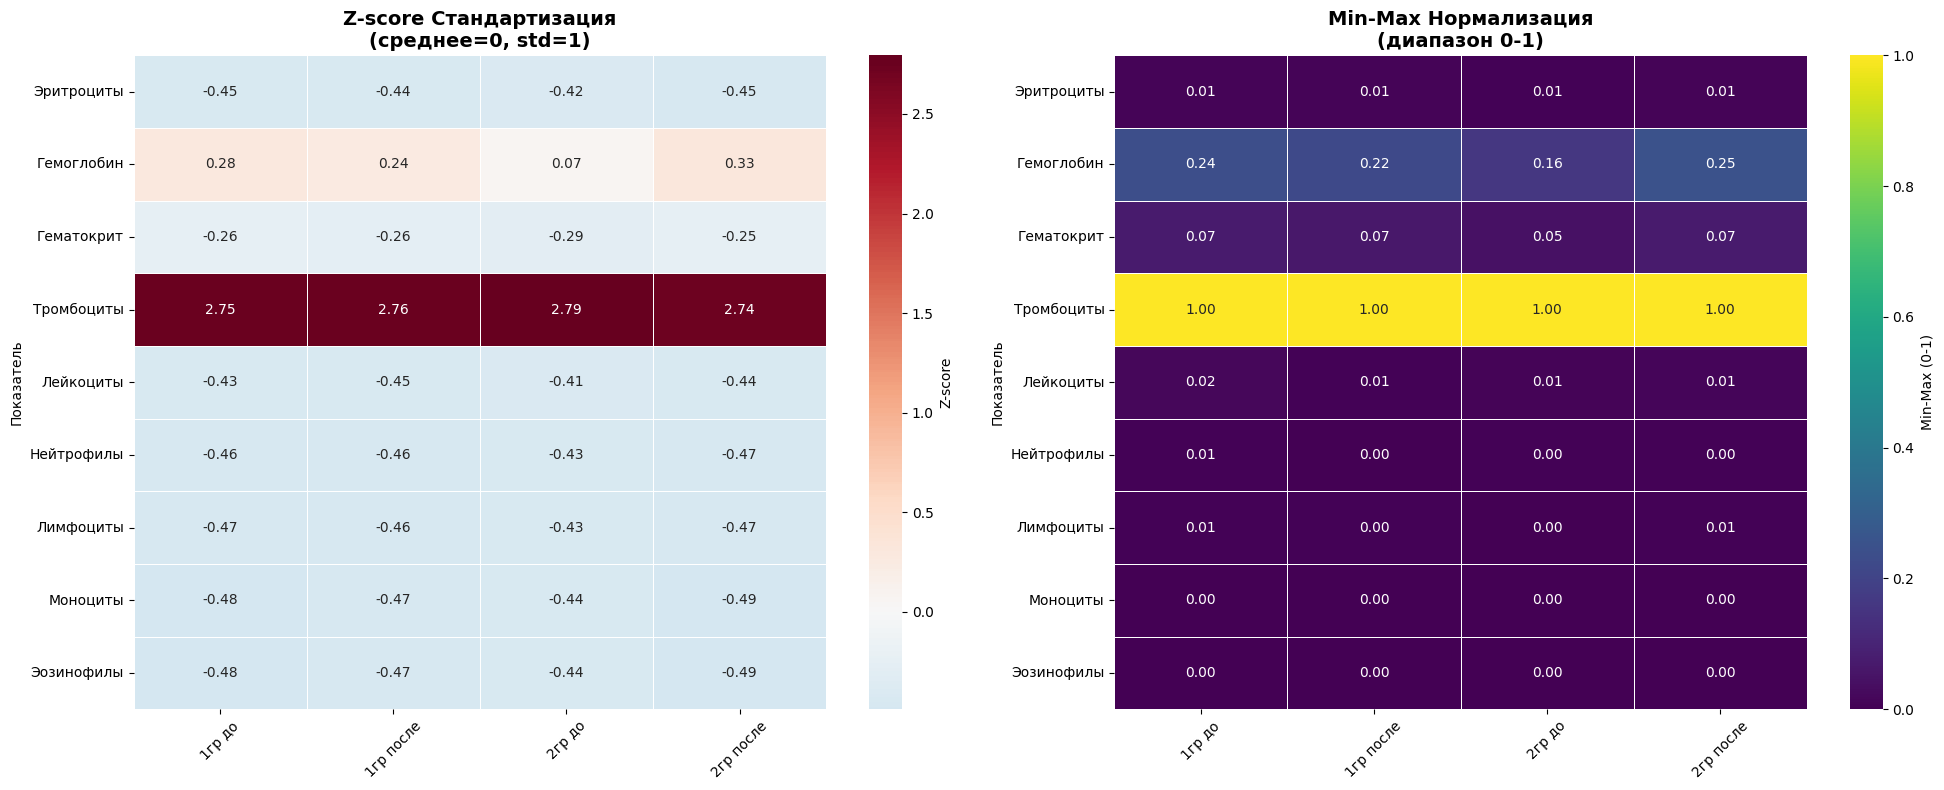

In [ ]:
# Создаем subplot для сравнения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Подготовка данных для тепловых карт
heatmap_zscore = df_zscore.set_index('Показатель')
heatmap_zscore.columns = ['1гр до', '1гр после', '2гр до', '2гр после']

heatmap_minmax = df_minmax.set_index('Показатель')
heatmap_minmax.columns = ['1гр до', '1гр после', '2гр до', '2гр после']

# Тепловая карта Z-score
sns.heatmap(heatmap_zscore, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Z-score'},
            ax=ax1)
ax1.set_title('Z-score Стандартизация\n(среднее=0, std=1)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Тепловая карта Min-Max
sns.heatmap(heatmap_minmax, 
            annot=True, 
            cmap='viridis',
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Min-Max (0-1)'},
            ax=ax2)
ax2.set_title('Min-Max Нормализация\n(диапазон 0-1)', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

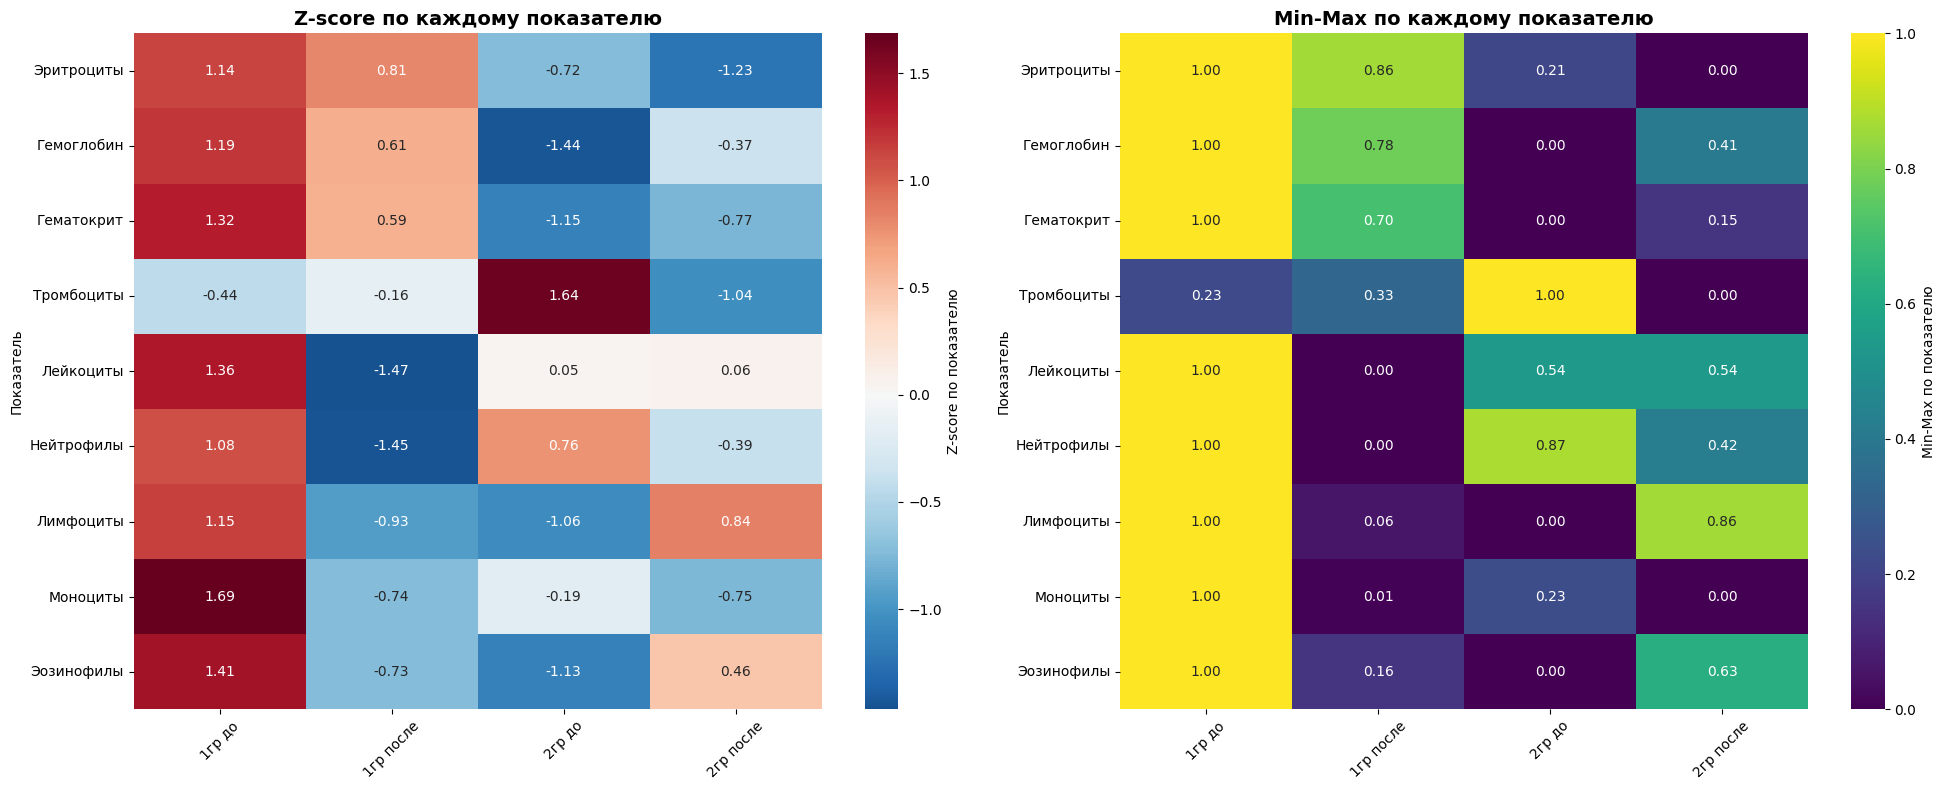

In [ ]:
# Нормализация по каждому показателю отдельно (по строкам)
df_row_normalized = df.copy()

for i in range(len(df)):
    row_data = df.iloc[i][numeric_columns].values.reshape(1, -1)
    
    # Z-score по строке
    z_row = StandardScaler().fit_transform(row_data.T).T
    # Min-Max по строке  
    mm_row = MinMaxScaler().fit_transform(row_data.T).T
    
    df_row_normalized.loc[i, [f'z_{col}' for col in numeric_columns]] = z_row.flatten()
    df_row_normalized.loc[i, [f'mm_{col}' for col in numeric_columns]] = mm_row.flatten()

# Тепловая карта с Z-score по строкам
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

z_columns = [f'z_{col}' for col in numeric_columns]
heatmap_z_row = df_row_normalized[['Показатель'] + z_columns].set_index('Показатель')
heatmap_z_row.columns = ['1гр до', '1гр после', '2гр до', '2гр после']

mm_columns = [f'mm_{col}' for col in numeric_columns]
heatmap_mm_row = df_row_normalized[['Показатель'] + mm_columns].set_index('Показатель')
heatmap_mm_row.columns = ['1гр до', '1гр после', '2гр до', '2гр после']

sns.heatmap(heatmap_z_row, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax1,
            cbar_kws={'label': 'Z-score по показателю'})
ax1.set_title('Z-score по каждому показателю', fontsize=14, fontweight='bold')

sns.heatmap(heatmap_mm_row, annot=True, cmap='viridis', fmt='.2f', ax=ax2,
            cbar_kws={'label': 'Min-Max по показателю'})
ax2.set_title('Min-Max по каждому показателю', fontsize=14, fontweight='bold')

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

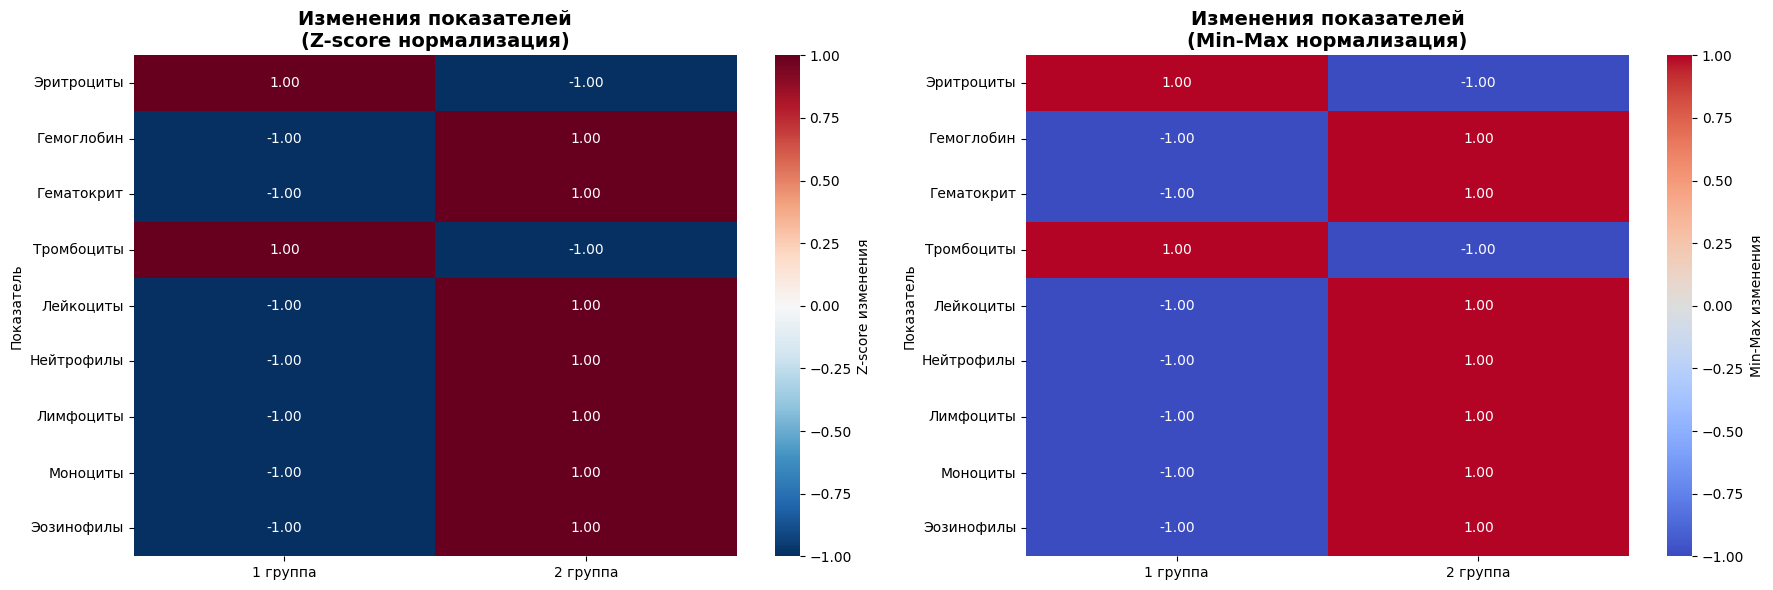

In [ ]:
# Анализ изменений с нормализацией
changes_data = []
for i, row in df.iterrows():
    indicator = row['Показатель']
    
    # Абсолютные изменения
    change_1 = row['1гр_после'] - row['1гр_до']
    change_2 = row['2гр_после'] - row['2гр_до']
    
    # Относительные изменения (%)
    rel_change_1 = (change_1 / row['1гр_до']) * 100 if row['1гр_до'] != 0 else 0
    rel_change_2 = (change_2 / row['2гр_до']) * 100 if row['2гр_до'] != 0 else 0
    
    changes_data.append({
        'Показатель': indicator,
        '1гр_абс': change_1,
        '2гр_абс': change_2,
        '1гр_%': rel_change_1,
        '2гр_%': rel_change_2
    })

df_changes = pd.DataFrame(changes_data)

# Нормализуем изменения
changes_for_norm = df_changes[['1гр_абс', '2гр_абс']]
changes_z = StandardScaler().fit_transform(changes_for_norm.T).T
changes_mm = MinMaxScaler(feature_range=(-1, 1)).fit_transform(changes_for_norm.T).T

df_changes[['1гр_абс_z', '2гр_абс_z']] = changes_z
df_changes[['1гр_абс_mm', '2гр_абс_mm']] = changes_mm

# Финальная тепловая карта изменений
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

heatmap_changes_z = df_changes[['Показатель', '1гр_абс_z', '2гр_абс_z']].set_index('Показатель')
heatmap_changes_z.columns = ['1 группа', '2 группа']

heatmap_changes_mm = df_changes[['Показатель', '1гр_абс_mm', '2гр_абс_mm']].set_index('Показатель')
heatmap_changes_mm.columns = ['1 группа', '2 группа']

sns.heatmap(heatmap_changes_z, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax1,
            cbar_kws={'label': 'Z-score изменения'})
ax1.set_title('Изменения показателей\n(Z-score нормализация)', fontsize=14, fontweight='bold')

sns.heatmap(heatmap_changes_mm, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax2,
            cbar_kws={'label': 'Min-Max изменения'})
ax2.set_title('Изменения показателей\n(Min-Max нормализация)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("КЛЮЧ ДЛЯ ИНТЕРПРЕТАЦИИ:")
print("Z-score стандартизация:")
print("   < -1.0: Значительно ниже среднего")
print("   -1.0 до -0.5: Ниже среднего") 
print("   -0.5 до 0.5: Около среднего")
print("   0.5 до 1.0: Выше среднего")
print("   > 1.0: Значительно выше среднего")
print("\nMin-Max нормализация:")
print("   0.0-0.2: Минимальные значения")
print("   0.2-0.8: Средний диапазон")
print("   0.8-1.0: Максимальные значения")
print("\nИзменения (тепловые карты):")
print("   🔵 Синий: Уменьшение показателя")
print("   🔴 Красный: Увеличение показателя")

КЛЮЧ ДЛЯ ИНТЕРПРЕТАЦИИ:
Z-score стандартизация:
   < -1.0: Значительно ниже среднего
   -1.0 до -0.5: Ниже среднего
   -0.5 до 0.5: Около среднего
   0.5 до 1.0: Выше среднего
   > 1.0: Значительно выше среднего

Min-Max нормализация:
   0.0-0.2: Минимальные значения
   0.2-0.8: Средний диапазон
   0.8-1.0: Максимальные значения

Изменения (тепловые карты):
   🔵 Синий: Уменьшение показателя
   🔴 Красный: Увеличение показателя


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Исходные данные по всем кроликам
raw_data = {
    '1 группа': {
        'Эритроциты_до': [5.92, 5.1, 4.64], 'Эритроциты_после': [5.48, 5.31, 4.64],
        'Гемоглобин_до': [116, 101, 100], 'Гемоглобин_после': [111, 99, 101],
        'Гематокрит_до': [34.9, 30.4, 29.6], 'Гематокрит_после': [33.1, 29.9, 29.2],
        'Тромбоциты_до': [137, 671, 528], 'Тромбоциты_после': [145, 686, 573],
        'Лейкоциты_до': [9.9, 5.34, 6.25], 'Лейкоциты_после': [2.74, 3.48, 4.25],
        'Нейтрофилы_до': [3.32, 3.52, 2.69], 'Нейтрофилы_после': [0.52, 0.99, 1.33],
        'Лимфоциты_до': [4.27, 1.43, 2.21], 'Лимфоциты_после': [1.68, 1.96, 2.3],
        'Моноциты_до': [1.62, 0.25, 1.05], 'Моноциты_после': [0.24, 0.46, 0.54],
        'Эозинофилы_до': [0.16, 0.13, 0.24], 'Эозинофилы_после': [0.13, 0.06, 0.07]
    },
    '2 группа': {
        'Эритроциты_до': [4.75, 4.96, 4.63], 'Эритроциты_после': [4.71, 4.12, 5.15],
        'Гемоглобин_до': [97, 102, 91], 'Гемоглобин_после': [103, 95, 103],
        'Гематокрит_до': [28.5, 30.5, 26.8], 'Гематокрит_после': [29.1, 26.9, 31.2],
        'Тромбоциты_до': [960, 433, 448], 'Тромбоциты_после': [339, 428, 422],
        'Лейкоциты_до': [6.57, 6.41, 3.4], 'Лейкоциты_после': [3.33, 2.75, 10.37],
        'Нейтрофилы_до': [4.74, 2.72, 1.22], 'Нейтрофилы_после': [1.14, 0.84, 3.68],
        'Лимфоциты_до': [1.15, 2.83, 1.84], 'Лимфоциты_после': [1.6, 1.32, 4.7],
        'Моноциты_до': [0.6, 0.72, 0.3], 'Моноциты_после': [0.49, 0.49, 0.25],
        'Эозинофилы_до': [0.07, 0.1, 0.04], 'Эозинофилы_после': [0.05, 0.11, 0.25]
    }
}

# Создаем DataFrame для сравнения средних
indicators = ['Эритроциты', 'Гемоглобин', 'Гематокрит', 'Тромбоциты', 'Лейкоциты', 
              'Нейтрофилы', 'Лимфоциты', 'Моноциты', 'Эозинофилы']

comparison_data = []
for indicator in indicators:
    # Средние значения для 1 группы
    g1_before = np.mean(raw_data['1 группа'][f'{indicator}_до'])
    g1_after = np.mean(raw_data['1 группа'][f'{indicator}_после'])
    g1_change = g1_after - g1_before
    g1_change_pct = (g1_change / g1_before) * 100 if g1_before != 0 else 0
    
    # Средние значения для 2 группы
    g2_before = np.mean(raw_data['2 группа'][f'{indicator}_до'])
    g2_after = np.mean(raw_data['2 группа'][f'{indicator}_после'])
    g2_change = g2_after - g2_before
    g2_change_pct = (g2_change / g2_before) * 100 if g2_before != 0 else 0
    
    # Разница между группами в изменениях
    diff_change = g2_change - g1_change
    
    comparison_data.append({
        'Показатель': indicator,
        '1гр_до': g1_before, '1гр_после': g1_after, '1гр_изменение': g1_change, '1гр_%': g1_change_pct,
        '2гр_до': g2_before, '2гр_после': g2_after, '2гр_изменение': g2_change, '2гр_%': g2_change_pct,
        'Разница_изменений': diff_change
    })

df_comparison = pd.DataFrame(comparison_data)
print("СРАВНЕНИЕ СРЕДНИХ ПОКАЗАТЕЛЕЙ:")
print(df_comparison.round(3))

СРАВНЕНИЕ СРЕДНИХ ПОКАЗАТЕЛЕЙ:
   Показатель   1гр_до  1гр_после  1гр_изменение   1гр_%   2гр_до  2гр_после  \
0  Эритроциты    5.220      5.143         -0.077  -1.469    4.780      4.660   
1  Гемоглобин  105.667    103.667         -2.000  -1.893   96.667    100.333   
2  Гематокрит   31.633     30.733         -0.900  -2.845   28.600     29.067   
3  Тромбоциты  445.333    468.000         22.667   5.090  613.667    396.333   
4   Лейкоциты    7.163      3.490         -3.673 -51.280    5.460      5.483   
5  Нейтрофилы    3.177      0.947         -2.230 -70.199    2.893      1.887   
6   Лимфоциты    2.637      1.980         -0.657 -24.905    1.940      2.540   
7    Моноциты    0.973      0.413         -0.560 -57.534    0.540      0.410   
8  Эозинофилы    0.177      0.087         -0.090 -50.943    0.070      0.137   

   2гр_изменение   2гр_%  Разница_изменений  
0         -0.120  -2.510             -0.043  
1          3.667   3.793              5.667  
2          0.467   1.632      

In [ ]:
# Статистический тест для сравнения изменений между группами
statistical_results = []

for indicator in indicators:
    # Изменения для каждого животного в 1 группе
    g1_changes = []
    for i in range(3):  # по 3 животным в каждой группе
        before = raw_data['1 группа'][f'{indicator}_до'][i]
        after = raw_data['1 группа'][f'{indicator}_после'][i]
        g1_changes.append(after - before)
    
    # Изменения для каждого животного во 2 группе
    g2_changes = []
    for i in range(3):
        before = raw_data['2 группа'][f'{indicator}_до'][i]
        after = raw_data['2 группа'][f'{indicator}_после'][i]
        g2_changes.append(after - before)
    
    # T-тест для независимых выборок
    t_stat, p_value = stats.ttest_ind(g1_changes, g2_changes)
    
    # Проверка нормальности распределения
    _, p_normality_g1 = stats.shapiro(g1_changes)
    _, p_normality_g2 = stats.shapiro(g2_changes)
    
    # Если распределение не нормальное, используем Манна-Уитни
    if p_normality_g1 < 0.05 or p_normality_g2 < 0.05:
        u_stat, p_value_mw = stats.mannwhitneyu(g1_changes, g2_changes)
        test_used = 'Mann-Whitney'
        p_value_final = p_value_mw
    else:
        test_used = 'T-test'
        p_value_final = p_value
    
    statistical_results.append({
        'Показатель': indicator,
        'Тест': test_used,
        'p_value': p_value_final,
        'Значимость': 'ДА' if p_value_final < 0.05 else 'нет',
        '1гр_изм_среднее': np.mean(g1_changes),
        '2гр_изм_среднее': np.mean(g2_changes),
        'Разница_средних': np.mean(g2_changes) - np.mean(g1_changes)
    })

df_stats = pd.DataFrame(statistical_results)
print("\nСТАТИСТИЧЕСКИЙ АНАЛИЗ РАЗЛИЧИЙ:")
print(df_stats.round(4))


СТАТИСТИЧЕСКИЙ АНАЛИЗ РАЗЛИЧИЙ:
   Показатель          Тест  p_value Значимость  1гр_изм_среднее  \
0  Эритроциты        T-test   0.9261        нет          -0.0767   
1  Гемоглобин        T-test   0.3890        нет          -2.0000   
2  Гематокрит        T-test   0.5927        нет          -0.9000   
3  Тромбоциты        T-test   0.3010        нет          22.6667   
4   Лейкоциты  Mann-Whitney   1.0000        нет          -3.6733   
5  Нейтрофилы        T-test   0.5459        нет          -2.2300   
6   Лимфоциты        T-test   0.4751        нет          -0.6567   
7    Моноциты        T-test   0.4053        нет          -0.5600   
8  Эозинофилы        T-test   0.1333        нет          -0.0900   

   2гр_изм_среднее  Разница_средних  
0          -0.1200          -0.0433  
1           3.6667           5.6667  
2           0.4667           1.3667  
3        -217.3333        -240.0000  
4           0.0233           3.6967  
5          -1.0067           1.2233  
6           0.6000  

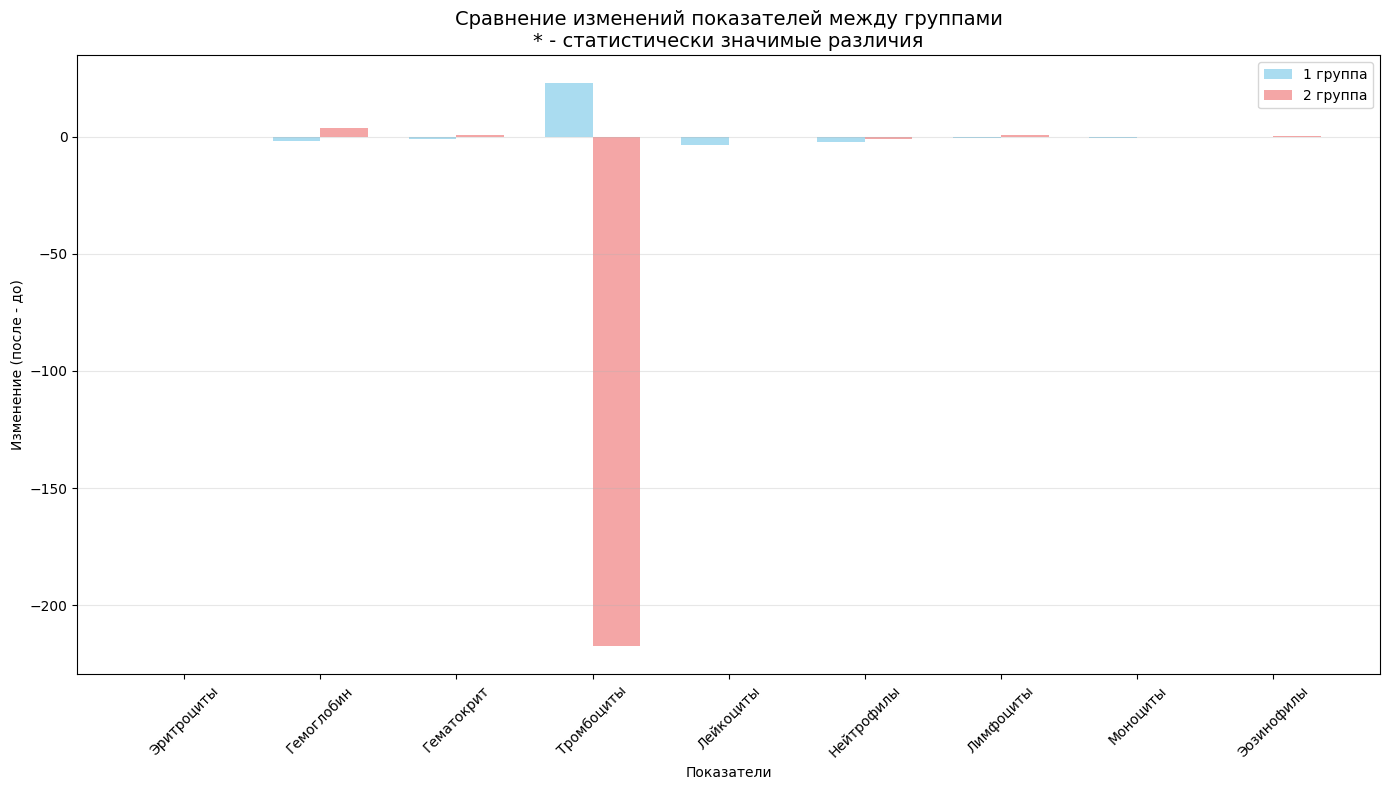

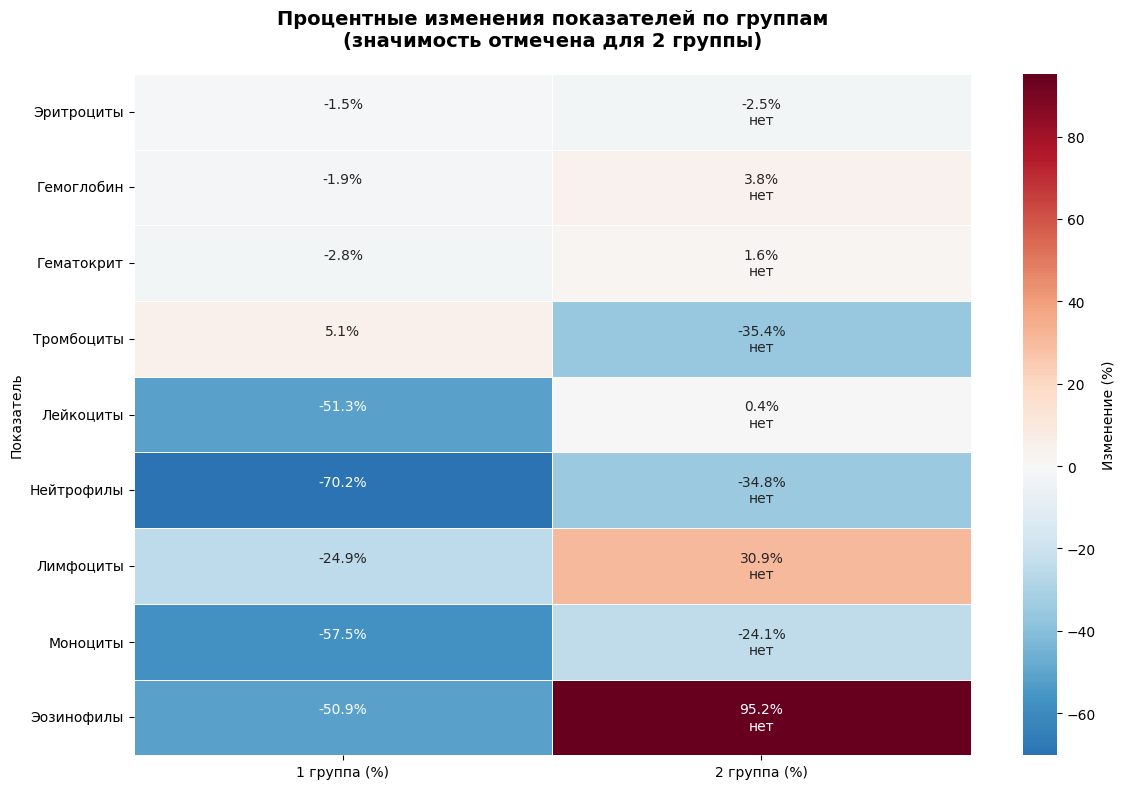

In [ ]:
# 1. Столбчатая диаграмма изменений по группам
plt.figure(figsize=(14, 8))
x = np.arange(len(indicators))
width = 0.35

plt.bar(x - width/2, df_comparison['1гр_изменение'], width, label='1 группа', alpha=0.7, color='skyblue')
plt.bar(x + width/2, df_comparison['2гр_изменение'], width, label='2 группа', alpha=0.7, color='lightcoral')

# Подсветка значимых различий
for i, (_, row) in enumerate(df_stats.iterrows()):
    if row['Значимость'] == 'ДА':
        plt.annotate('*', (x[i], max(df_comparison.loc[i, '1гр_изменение'], 
                                   df_comparison.loc[i, '2гр_изменение']) + 0.1), 
                    ha='center', fontsize=16, color='red')

plt.xlabel('Показатели')
plt.ylabel('Изменение (после - до)')
plt.title('Сравнение изменений показателей между группами\n* - статистически значимые различия', fontsize=14)
plt.xticks(x, indicators, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Тепловая карта сравнения эффективности
plt.figure(figsize=(12, 8))

# Создаем матрицу для тепловой карты
heatmap_data = df_comparison[['1гр_%', '2гр_%']].copy()
heatmap_data.index = df_comparison['Показатель']
heatmap_data.columns = ['1 группа (%)', '2 группа (%)']

# Добавляем аннотации значимости
annotations = []
for i in range(len(heatmap_data)):
    row = []
    for j in range(2):
        value = heatmap_data.iloc[i, j]
        sig = df_stats.iloc[i]['Значимость'] if j == 1 else ''
        row.append(f'{value:.1f}%\n{sig}')
    annotations.append(row)

sns.heatmap(heatmap_data, 
            annot=annotations, 
            cmap='RdBu_r', 
            center=0,
            fmt='',
            linewidths=0.5,
            cbar_kws={'label': 'Изменение (%)'})

plt.title('Процентные изменения показателей по группам\n(значимость отмечена для 2 группы)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Исходные данные по всем группам
raw_data = {
    '1 группа': {
        'Эритроциты_до': [5.92, 5.1, 4.64], 'Эритроциты_после': [5.48, 5.31, 4.64],
        'Гемоглобин_до': [116, 101, 100], 'Гемоглобин_после': [111, 99, 101],
        'Гематокрит_до': [34.9, 30.4, 29.6], 'Гематокрит_после': [33.1, 29.9, 29.2],
        'Тромбоциты_до': [137, 671, 528], 'Тромбоциты_после': [145, 686, 573],
        'Лейкоциты_до': [9.9, 5.34, 6.25], 'Лейкоциты_после': [2.74, 3.48, 4.25],
        'Нейтрофилы_до': [3.32, 3.52, 2.69], 'Нейтрофилы_после': [0.52, 0.99, 1.33],
        'Лимфоциты_до': [4.27, 1.43, 2.21], 'Лимфоциты_после': [1.68, 1.96, 2.3],
        'Моноциты_до': [1.62, 0.25, 1.05], 'Моноциты_после': [0.24, 0.46, 0.54],
        'Эозинофилы_до': [0.16, 0.13, 0.24], 'Эозинофилы_после': [0.13, 0.06, 0.07]
    },
    '2 группа': {
        'Эритроциты_до': [4.75, 4.96, 4.63], 'Эритроциты_после': [4.71, 4.12, 5.15],
        'Гемоглобин_до': [97, 102, 91], 'Гемоглобин_после': [103, 95, 103],
        'Гематокрит_до': [28.5, 30.5, 26.8], 'Гематокрит_после': [29.1, 26.9, 31.2],
        'Тромбоциты_до': [960, 433, 448], 'Тромбоциты_после': [339, 428, 422],
        'Лейкоциты_до': [6.57, 6.41, 3.4], 'Лейкоциты_после': [3.33, 2.75, 10.37],
        'Нейтрофилы_до': [4.74, 2.72, 1.22], 'Нейтрофилы_после': [1.14, 0.84, 3.68],
        'Лимфоциты_до': [1.15, 2.83, 1.84], 'Лимфоциты_после': [1.6, 1.32, 4.7],
        'Моноциты_до': [0.6, 0.72, 0.3], 'Моноциты_после': [0.49, 0.49, 0.25],
        'Эозинофилы_до': [0.07, 0.1, 0.04], 'Эозинофилы_после': [0.05, 0.11, 0.25]
    }
}

# Контрольные значения (норма)
control_ranges = {
    'Эритроциты': [3.4, 6.5],
    'Гемоглобин': [80, 170],
    'Гематокрит': [25, 42],
    'Тромбоциты': [1100, 1250],
    'Лейкоциты': [4.3, 13.5],
    'Нейтрофилы': [0.5, 6.6],
    'Лимфоциты': [1.0, 6.8],
    'Моноциты': [0.08, 1.51],
    'Эозинофилы': [0.0, 0.51]
}

# Средние значения контрольной группы (середина диапазона)
control_means = {indicator: np.mean(range_val) for indicator, range_val in control_ranges.items()}

In [ ]:
# Сравнение конечных значений с контрольной группой
comparison_results = []

indicators = list(control_ranges.keys())

for indicator in indicators:
    # Средние значения после эксперимента
    g1_after = np.mean(raw_data['1 группа'][f'{indicator}_после'])
    g2_after = np.mean(raw_data['2 группа'][f'{indicator}_после'])
    control_mean = control_means[indicator]
    control_min, control_max = control_ranges[indicator]
    
    # Отклонение от нормы в %
    g1_deviation = ((g1_after - control_mean) / control_mean) * 100
    g2_deviation = ((g2_after - control_mean) / control_mean) * 100
    
    # Проверка нахождения в нормальном диапазоне
    g1_in_range = control_min <= g1_after <= control_max
    g2_in_range = control_min <= g2_after <= control_max
    
    # Близость к норме (меньше отклонение = лучше)
    g1_closeness = abs(g1_deviation)
    g2_closeness = abs(g2_deviation)
    
    # Какая группа ближе к норме?
    if g1_closeness < g2_closeness:
        better_group = '1 группа'
    elif g2_closeness < g1_closeness:
        better_group = '2 группа'
    else:
        better_group = 'одинаково'
    
    comparison_results.append({
        'Показатель': indicator,
        'Контроль_среднее': control_mean,
        'Контроль_диапазон': f'{control_min}-{control_max}',
        '1гр_после': g1_after,
        '2гр_после': g2_after,
        '1гр_отклонение_%': g1_deviation,
        '2гр_отклонение_%': g2_deviation,
        '1гр_в_норме': 'ДА' if g1_in_range else 'НЕТ',
        '2гр_в_норме': 'ДА' if g2_in_range else 'НЕТ',
        'Ближе_к_норме': better_group
    })

df_control_comparison = pd.DataFrame(comparison_results)
print("СРАВНЕНИЕ С КОНТРОЛЬНОЙ ГРУППОЙ (НОРМА):")
print(df_control_comparison.round(3))

СРАВНЕНИЕ С КОНТРОЛЬНОЙ ГРУППОЙ (НОРМА):
   Показатель  Контроль_среднее Контроль_диапазон  1гр_после  2гр_после  \
0  Эритроциты             4.950           3.4-6.5      5.143      4.660   
1  Гемоглобин           125.000            80-170    103.667    100.333   
2  Гематокрит            33.500             25-42     30.733     29.067   
3  Тромбоциты          1175.000         1100-1250    468.000    396.333   
4   Лейкоциты             8.900          4.3-13.5      3.490      5.483   
5  Нейтрофилы             3.550           0.5-6.6      0.947      1.887   
6   Лимфоциты             3.900           1.0-6.8      1.980      2.540   
7    Моноциты             0.795         0.08-1.51      0.413      0.410   
8  Эозинофилы             0.255          0.0-0.51      0.087      0.137   

   1гр_отклонение_%  2гр_отклонение_% 1гр_в_норме 2гр_в_норме Ближе_к_норме  
0             3.906            -5.859          ДА          ДА      1 группа  
1           -17.067           -19.733          ДА   

In [ ]:
# Статистический анализ: сравниваем с контрольным значением
statistical_analysis = []

for indicator in indicators:
    control_mean = control_means[indicator]
    
    # Данные для 1 группы
    g1_data = raw_data['1 группа'][f'{indicator}_после']
    
    # Одновыборочный t-тест для 1 группы против контрольного значения
    t_stat_g1, p_value_g1 = stats.ttest_1samp(g1_data, control_mean)
    
    # Данные для 2 группы
    g2_data = raw_data['2 группа'][f'{indicator}_после']
    
    # Одновыборочный t-тест для 2 группы против контрольного значения
    t_stat_g2, p_value_g2 = stats.ttest_1samp(g2_data, control_mean)
    
    # Эффект размера (Cohen's d)
    cohen_d_g1 = (np.mean(g1_data) - control_mean) / np.std(g1_data, ddof=1)
    cohen_d_g2 = (np.mean(g2_data) - control_mean) / np.std(g2_data, ddof=1)
    
    statistical_analysis.append({
        'Показатель': indicator,
        'p_1гр_vs_контроль': p_value_g1,
        'p_2гр_vs_контроль': p_value_g2,
        'Значимость_1гр': 'ДА' if p_value_g1 < 0.05 else 'нет',
        'Значимость_2гр': 'ДА' if p_value_g2 < 0.05 else 'нет',
        'Эффект_1гр': cohen_d_g1,
        'Эффект_2гр': cohen_d_g2,
        'Сила_эффекта_1гр': 'большой' if abs(cohen_d_g1) >= 0.8 else 'средний' if abs(cohen_d_g1) >= 0.5 else 'малый',
        'Сила_эффекта_2гр': 'большой' if abs(cohen_d_g2) >= 0.8 else 'средний' if abs(cohen_d_g2) >= 0.5 else 'малый'
    })

df_stats_control = pd.DataFrame(statistical_analysis)
print("\nСТАТИСТИЧЕСКИЙ АНАЛИЗ ПРОТИВ КОНТРОЛЬНОЙ ГРУППЫ:")
print(df_stats_control.round(4))


СТАТИСТИЧЕСКИЙ АНАЛИЗ ПРОТИВ КОНТРОЛЬНОЙ ГРУППЫ:
   Показатель  p_1гр_vs_контроль  p_2гр_vs_контроль Значимость_1гр  \
0  Эритроциты             0.5295             0.4336            нет   
1  Гемоглобин             0.0290             0.0115             ДА   
2  Гематокрит             0.1477             0.0702            нет   
3  Тромбоциты             0.0503             0.0014            нет   
4   Лейкоциты             0.0064             0.2977             ДА   
5  Нейтрофилы             0.0080             0.2061             ДА   
6   Лимфоциты             0.0086             0.3360             ДА   
7    Моноциты             0.0510             0.0406            нет   
8  Эозинофилы             0.0164             0.1839             ДА   

  Значимость_2гр  Эффект_1гр  Эффект_2гр Сила_эффекта_1гр Сила_эффекта_2гр  
0            нет      0.4353     -0.5611            малый          средний  
1             ДА     -3.3182     -5.3405          большой          большой  
2            нет  

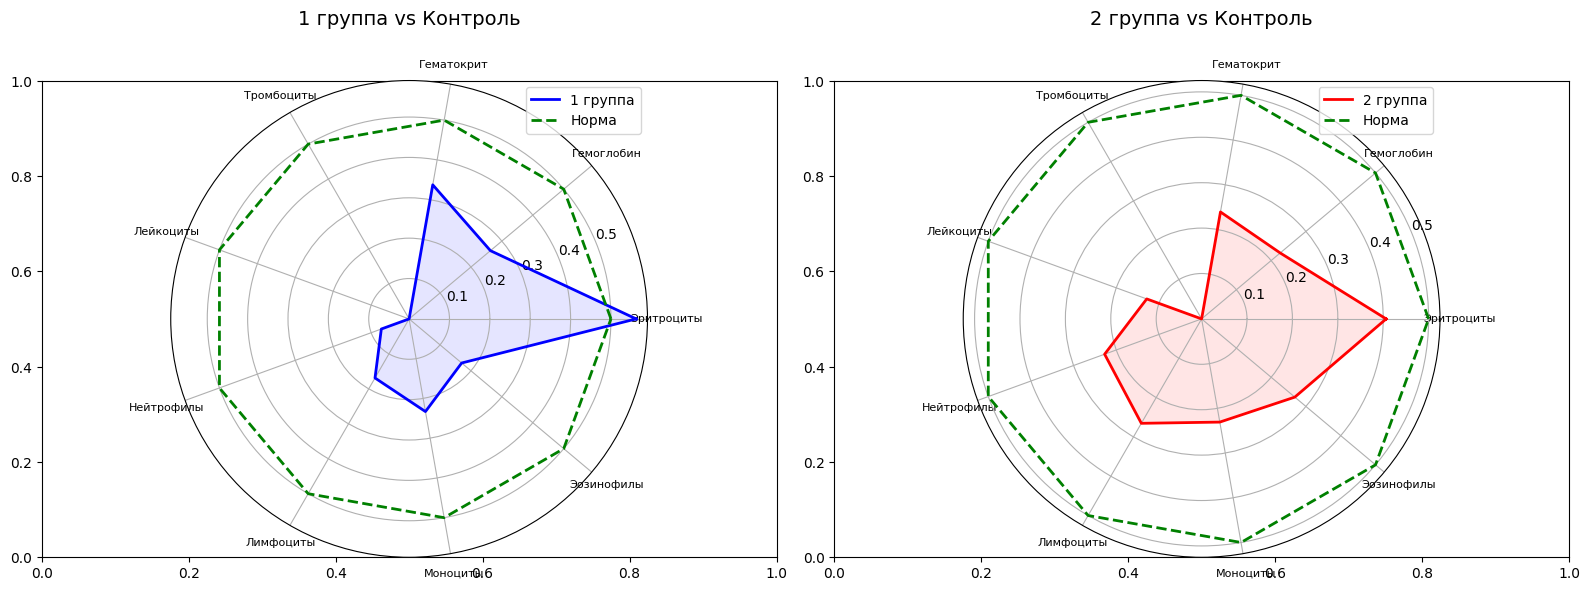

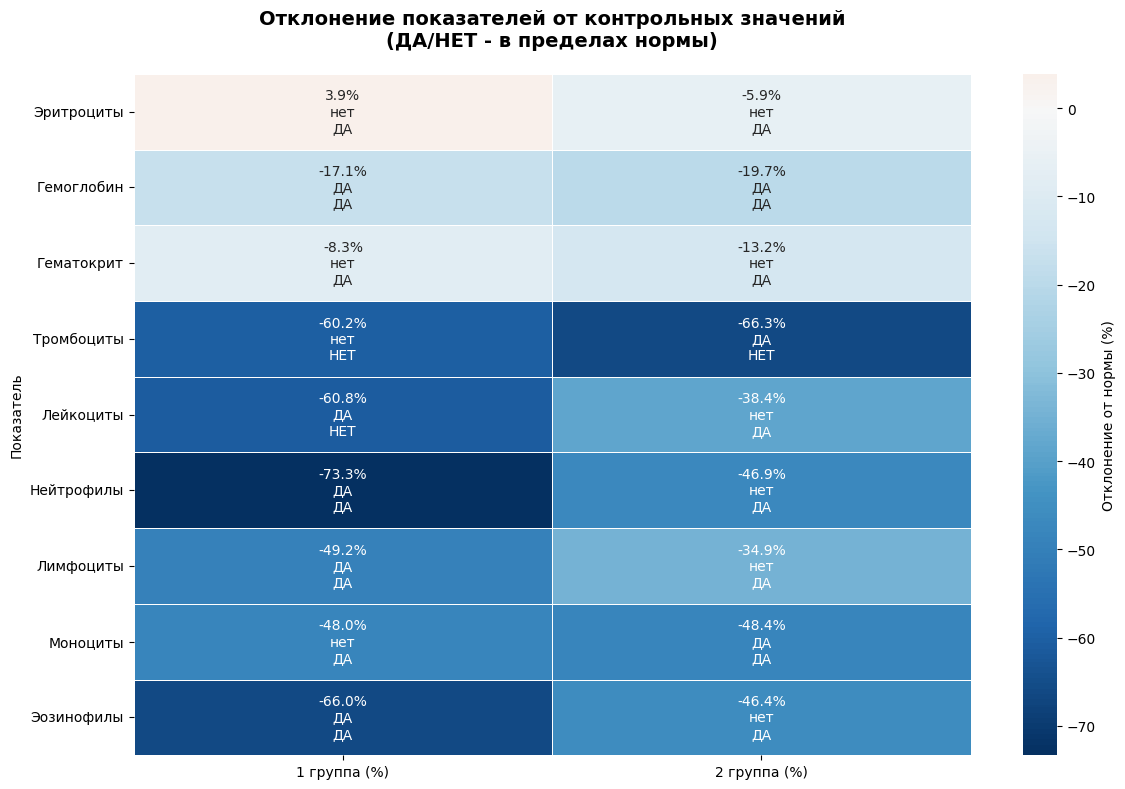

In [ ]:
# 1. Радар-диаграмма сравнения с нормой
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Нормализуем данные для радар-диаграммы
def normalize_for_radar(values, control_min, control_max):
    """Нормализует значения к диапазону 0-1 относительно контрольного диапазона"""
    return np.clip((values - control_min) / (control_max - control_min), 0, 1)

# Подготовка данных для радар-диаграммы
categories = indicators
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Замыкаем круг

# 1 группа vs контроль
g1_normalized = []
control_normalized = []
for indicator in indicators:
    control_min, control_max = control_ranges[indicator]
    g1_normalized.append(normalize_for_radar(df_control_comparison[df_control_comparison['Показатель'] == indicator]['1гр_после'].values[0], 
                                           control_min, control_max))
    control_normalized.append(0.5)  # Середина диапазона = идеал

g1_normalized += g1_normalized[:1]
control_normalized += control_normalized[:1]

ax1 = plt.subplot(121, polar=True)
plt.xticks(angles[:-1], categories, size=8)
ax1.plot(angles, g1_normalized, linewidth=2, linestyle='solid', label='1 группа', color='blue')
ax1.fill(angles, g1_normalized, 'b', alpha=0.1)
ax1.plot(angles, control_normalized, linewidth=2, linestyle='dashed', label='Норма', color='green')
ax1.set_title('1 группа vs Контроль', size=14, y=1.1)
ax1.legend(loc='upper right')

# 2 группа vs контроль
g2_normalized = []
for indicator in indicators:
    control_min, control_max = control_ranges[indicator]
    g2_normalized.append(normalize_for_radar(df_control_comparison[df_control_comparison['Показатель'] == indicator]['2гр_после'].values[0], 
                                           control_min, control_max))

g2_normalized += g2_normalized[:1]

ax2 = plt.subplot(122, polar=True)
plt.xticks(angles[:-1], categories, size=8)
ax2.plot(angles, g2_normalized, linewidth=2, linestyle='solid', label='2 группа', color='red')
ax2.fill(angles, g2_normalized, 'r', alpha=0.1)
ax2.plot(angles, control_normalized, linewidth=2, linestyle='dashed', label='Норма', color='green')
ax2.set_title('2 группа vs Контроль', size=14, y=1.1)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 2. Тепловая карта отклонений от нормы
plt.figure(figsize=(12, 8))

heatmap_data = df_control_comparison[['Показатель', '1гр_отклонение_%', '2гр_отклонение_%']].set_index('Показатель')
heatmap_data.columns = ['1 группа (%)', '2 группа (%)']

# Добавляем аннотации со значимостью
annotations = []
for i, indicator in enumerate(indicators):
    row = []
    for j, col in enumerate(['1гр_отклонение_%', '2гр_отклонение_%']):
        value = df_control_comparison.iloc[i][col]
        sig_1 = df_stats_control.iloc[i]['Значимость_1гр'] if j == 0 else ''
        sig_2 = df_stats_control.iloc[i]['Значимость_2гр'] if j == 1 else ''
        in_range_1 = df_control_comparison.iloc[i]['1гр_в_норме'] if j == 0 else ''
        in_range_2 = df_control_comparison.iloc[i]['2гр_в_норме'] if j == 1 else ''
        
        annotation = f'{value:.1f}%'
        if j == 0:
            annotation += f'\n{sig_1}\n{in_range_1}'
        else:
            annotation += f'\n{sig_2}\n{in_range_2}'
        row.append(annotation)
    annotations.append(row)

sns.heatmap(heatmap_data, 
            annot=annotations, 
            cmap='RdBu_r', 
            center=0,
            fmt='',
            linewidths=0.5,
            cbar_kws={'label': 'Отклонение от нормы (%)'})

plt.title('Отклонение показателей от контрольных значений\n(ДА/НЕТ - в пределах нормы)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Анализ того, насколько группы приблизились к норме
norm_recovery_analysis = []

for indicator in indicators:
    control_min, control_max = control_ranges[indicator]
    control_mean = control_means[indicator]
    
    # Исходные отклонения (до)
    g1_before = np.mean(raw_data['1 группа'][f'{indicator}_до'])
    g2_before = np.mean(raw_data['2 группа'][f'{indicator}_до'])
    
    g1_before_dev = abs((g1_before - control_mean) / control_mean) * 100
    g2_before_dev = abs((g2_before - control_mean) / control_mean) * 100
    
    # Конечные отклонения (после)
    g1_after_dev = abs(df_control_comparison[df_control_comparison['Показатель'] == indicator]['1гр_отклонение_%'].values[0])
    g2_after_dev = abs(df_control_comparison[df_control_comparison['Показатель'] == indicator]['2гр_отклонение_%'].values[0])
    
    # Улучшение (снижение отклонения)
    g1_improvement = g1_before_dev - g1_after_dev
    g2_improvement = g2_before_dev - g2_after_dev
    
    # Какая группа лучше восстановила норму?
    if g1_improvement > g2_improvement:
        better_recovery = '1 группа'
    elif g2_improvement > g1_improvement:
        better_recovery = '2 группа'
    else:
        better_recovery = 'одинаково'
    
    norm_recovery_analysis.append({
        'Показатель': indicator,
        '1гр_исходное_отклонение_%': g1_before_dev,
        '1гр_конечное_отклонение_%': g1_after_dev,
        '1гр_улучшение_%': g1_improvement,
        '2гр_исходное_отклонение_%': g2_before_dev,
        '2гр_конечное_отклонение_%': g2_after_dev,
        '2гр_улучшение_%': g2_improvement,
        'Лучшее_восстановление': better_recovery
    })

df_recovery = pd.DataFrame(norm_recovery_analysis)
print("\nАНАЛИЗ ВОССТАНОВЛЕНИЯ НОРМЫ:")
print(df_recovery.round(3))


АНАЛИЗ ВОССТАНОВЛЕНИЯ НОРМЫ:
   Показатель  1гр_исходное_отклонение_%  1гр_конечное_отклонение_%  \
0  Эритроциты                      5.455                      3.906   
1  Гемоглобин                     15.467                     17.067   
2  Гематокрит                      5.572                      8.259   
3  Тромбоциты                     62.099                     60.170   
4   Лейкоциты                     19.513                     60.787   
5  Нейтрофилы                     10.516                     73.333   
6   Лимфоциты                     32.393                     49.231   
7    Моноциты                     22.432                     48.008   
8  Эозинофилы                     30.719                     66.013   

   1гр_улучшение_%  2гр_исходное_отклонение_%  2гр_конечное_отклонение_%  \
0            1.549                      3.434                      5.859   
1           -1.600                     22.667                     19.733   
2           -2.687             

In [ ]:
# Сводный отчет
print("="*70)
print("ИТОГОВЫЙ ОТЧЕТ: СРАВНЕНИЕ С КОНТРОЛЬНОЙ ГРУППОЙ")
print("="*70)

# Статистика по нахождению в норме
g1_in_norm = len(df_control_comparison[df_control_comparison['1гр_в_норме'] == 'ДА'])
g2_in_norm = len(df_control_comparison[df_control_comparison['2гр_в_норме'] == 'ДА'])

print(f"Показателей в пределах нормы:")
print(f"  1 группа: {g1_in_norm} из {len(indicators)} ({g1_in_norm/len(indicators)*100:.1f}%)")
print(f"  2 группа: {g2_in_norm} из {len(indicators)} ({g2_in_norm/len(indicators)*100:.1f}%)")

# Статистика по значимым отклонениям
g1_significant = len(df_stats_control[df_stats_control['Значимость_1гр'] == 'ДА'])
g2_significant = len(df_stats_control[df_stats_control['Значимость_2гр'] == 'ДА'])

print(f"\nСтатистически значимые отклонения от нормы:")
print(f"  1 группа: {g1_significant} показателей")
print(f"  2 группа: {g2_significant} показателей")

# Анализ восстановления нормы
g1_better_recovery = len(df_recovery[df_recovery['Лучшее_восстановление'] == '1 группа'])
g2_better_recovery = len(df_recovery[df_recovery['Лучшее_восстановление'] == '2 группа'])

print(f"\nЭффективность восстановления нормы:")
print(f"  1 группа лучше восстановила: {g1_better_recovery} показателей")
print(f"  2 группа лучше восстановила: {g2_better_recovery} показателей")

# Общие выводы
print(f"\nОБЩИЕ ВЫВОДЫ:")
if g1_in_norm > g2_in_norm and g1_significant < g2_significant:
    print("✅ 1 группа демонстрирует лучшие результаты по приближению к норме")
elif g2_in_norm > g1_in_norm and g2_significant < g1_significant:
    print("✅ 2 группа демонстрирует лучшие результаты по приближению к норме")
else:
    print("⚠️  Группы демонстрируют сопоставимые результаты")

print("="*70)

ИТОГОВЫЙ ОТЧЕТ: СРАВНЕНИЕ С КОНТРОЛЬНОЙ ГРУППОЙ
Показателей в пределах нормы:
  1 группа: 7 из 9 (77.8%)
  2 группа: 8 из 9 (88.9%)

Статистически значимые отклонения от нормы:
  1 группа: 5 показателей
  2 группа: 3 показателей

Эффективность восстановления нормы:
  1 группа лучше восстановила: 2 показателей
  2 группа лучше восстановила: 7 показателей

ОБЩИЕ ВЫВОДЫ:
✅ 2 группа демонстрирует лучшие результаты по приближению к норме


НОРМАЛИЗОВАННЫЕ ИЗМЕНЕНИЯ (RobustScaler):
   Показатель  1гр_норм_среднее  2гр_норм_среднее  p_value
0  Эритроциты             0.052             0.033    0.926
1  Гемоглобин            -0.753             1.618    0.389
2  Гематокрит            -0.293             0.279    0.593
3  Тромбоциты             9.568           -90.851    0.301
4   Лейкоциты            -1.453             0.093    0.396
5  Нейтрофилы            -0.849            -0.338    0.546
6   Лимфоциты            -0.191             0.335    0.475
7    Моноциты            -0.151             0.029    0.405
8  Эозинофилы             0.046             0.112    0.133


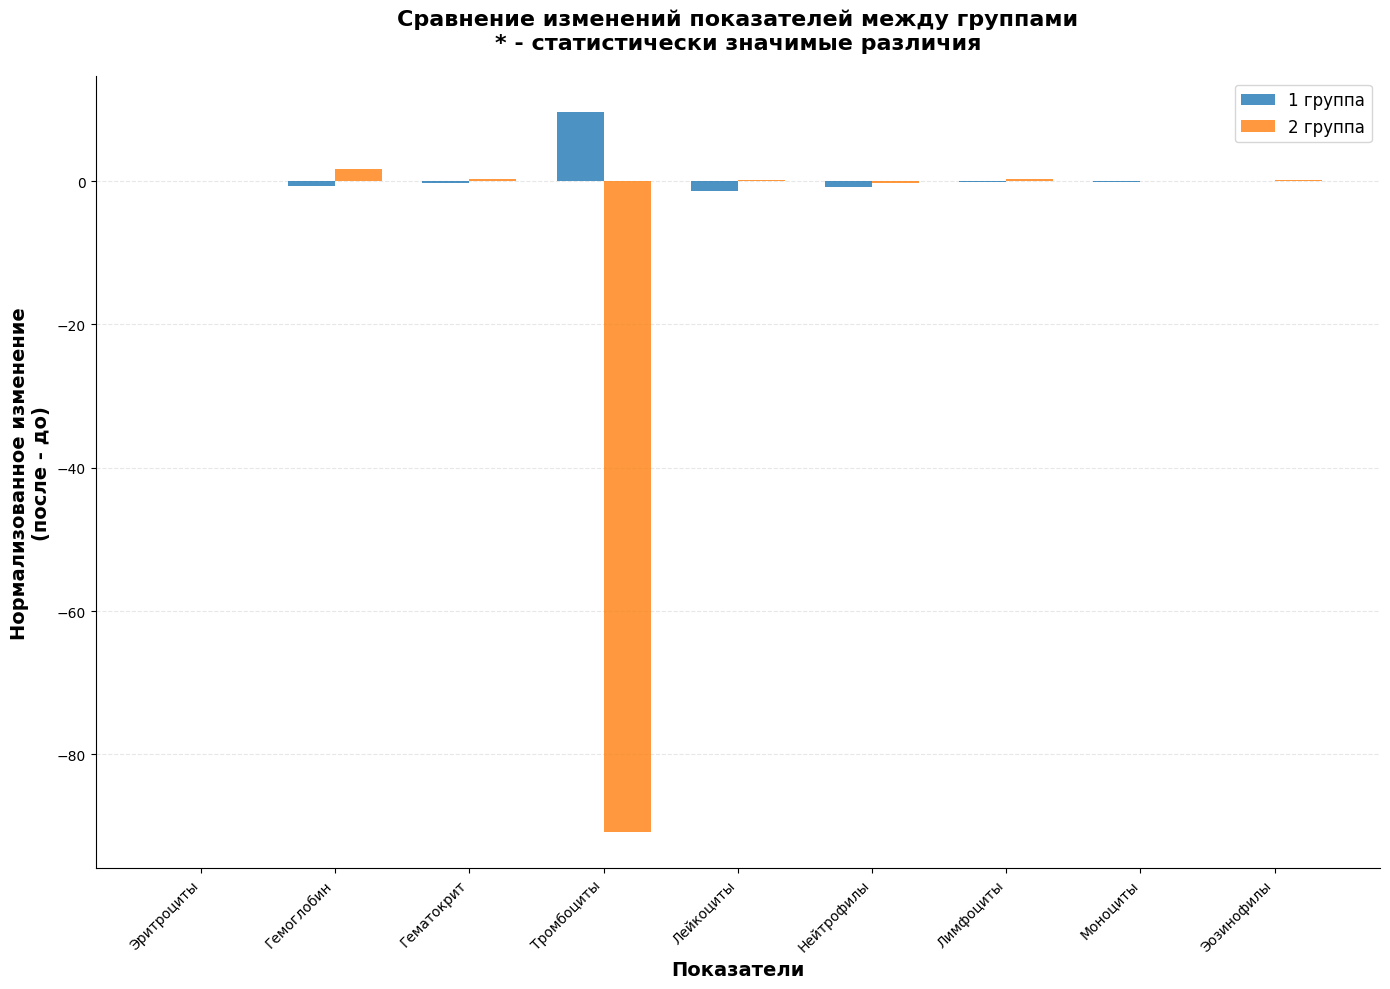

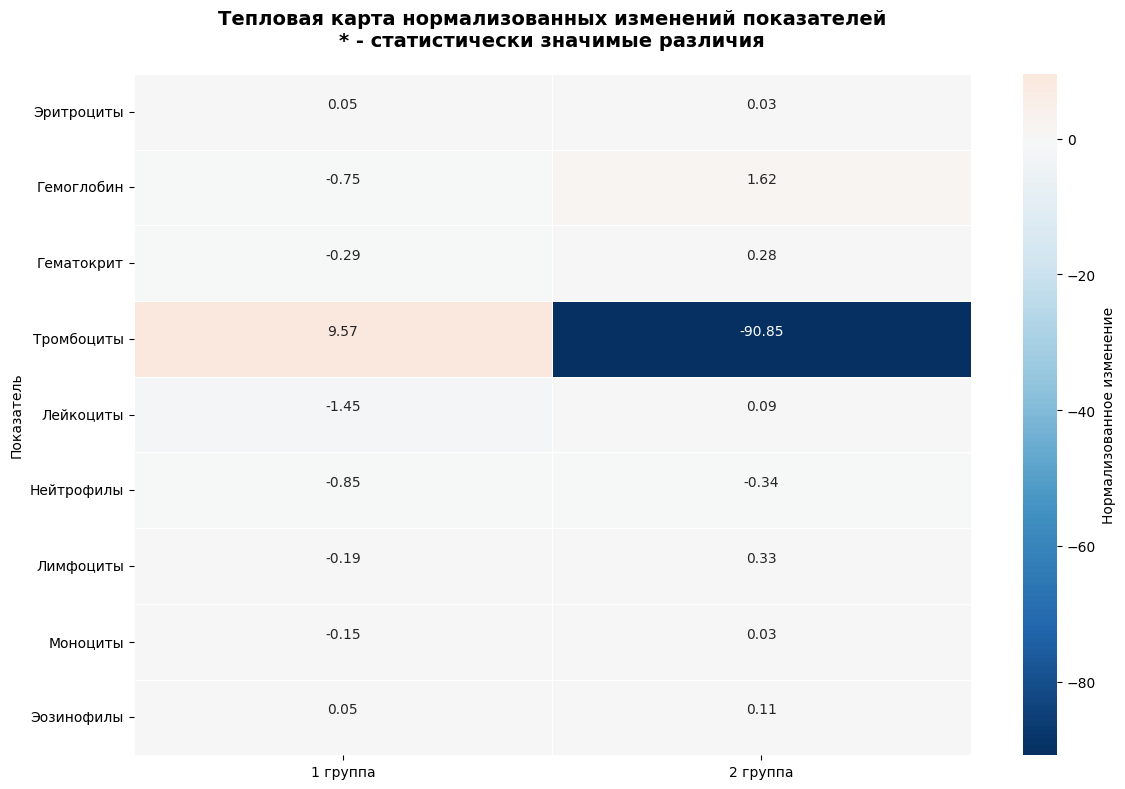


СТАТИСТИЧЕСКИЙ АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ ГРУППАМИ
Статистически значимые различия обнаружены в 0 из 9 показателей:


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Установим русский шрифт для графиков
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Исходные данные по всем кроликам
raw_data = {
    '1 группа': {
        'Эритроциты_до': [5.92, 5.1, 4.64], 'Эритроциты_после': [5.48, 5.31, 4.64],
        'Гемоглобин_до': [116, 101, 100], 'Гемоглобин_после': [111, 99, 101],
        'Гематокрит_до': [34.9, 30.4, 29.6], 'Гематокрит_после': [33.1, 29.9, 29.2],
        'Тромбоциты_до': [137, 671, 528], 'Тромбоциты_после': [145, 686, 573],
        'Лейкоциты_до': [9.9, 5.34, 6.25], 'Лейкоциты_после': [2.74, 3.48, 4.25],
        'Нейтрофилы_до': [3.32, 3.52, 2.69], 'Нейтрофилы_после': [0.52, 0.99, 1.33],
        'Лимфоциты_до': [4.27, 1.43, 2.21], 'Лимфоциты_после': [1.68, 1.96, 2.3],
        'Моноциты_до': [1.62, 0.25, 1.05], 'Моноциты_после': [0.24, 0.46, 0.54],
        'Эозинофилы_до': [0.16, 0.13, 0.24], 'Эозинофилы_после': [0.13, 0.06, 0.07]
    },
    '2 группа': {
        'Эритроциты_до': [4.75, 4.96, 4.63], 'Эритроциты_после': [4.71, 4.12, 5.15],
        'Гемоглобин_до': [97, 102, 91], 'Гемоглобин_после': [103, 95, 103],
        'Гематокрит_до': [28.5, 30.5, 26.8], 'Гематокрит_после': [29.1, 26.9, 31.2],
        'Тромбоциты_до': [960, 433, 448], 'Тромбоциты_после': [339, 428, 422],
        'Лейкоциты_до': [6.57, 6.41, 3.4], 'Лейкоциты_после': [3.33, 2.75, 10.37],
        'Нейтрофилы_до': [4.74, 2.72, 1.22], 'Нейтрофилы_после': [1.14, 0.84, 3.68],
        'Лимфоциты_до': [1.15, 2.83, 1.84], 'Лимфоциты_после': [1.6, 1.32, 4.7],
        'Моноциты_до': [0.6, 0.72, 0.3], 'Моноциты_после': [0.49, 0.49, 0.25],
        'Эозинофилы_до': [0.07, 0.1, 0.04], 'Эозинофилы_после': [0.05, 0.11, 0.25]
    }
}

# Создаем DataFrame для изменений
indicators = ['Эритроциты', 'Гемоглобин', 'Гематокрит', 'Тромбоциты', 'Лейкоциты', 
              'Нейтрофилы', 'Лимфоциты', 'Моноциты', 'Эозинофилы']

# Рассчитываем изменения для каждого животного
changes_data = []

for indicator in indicators:
    # Изменения для каждого животного в 1 группе
    g1_changes = []
    for i in range(3):
        before = raw_data['1 группа'][f'{indicator}_до'][i]
        after = raw_data['1 группа'][f'{indicator}_после'][i]
        g1_changes.append(after - before)
    
    # Изменения для каждого животного во 2 группе
    g2_changes = []
    for i in range(3):
        before = raw_data['2 группа'][f'{indicator}_до'][i]
        after = raw_data['2 группа'][f'{indicator}_после'][i]
        g2_changes.append(after - before)
    
    # Статистический тест
    t_stat, p_value = stats.ttest_ind(g1_changes, g2_changes)
    
    changes_data.append({
        'Показатель': indicator,
        '1гр_изменения': g1_changes,
        '2гр_изменения': g2_changes,
        '1гр_среднее': np.mean(g1_changes),
        '2гр_среднее': np.mean(g2_changes),
        'p_value': p_value
    })

df_changes = pd.DataFrame(changes_data)

# ПОДГОТОВКА ДАННЫХ ДЛЯ RobustScaler
# Собираем все изменения в один массив для нормализации
all_changes = []
for indicator in indicators:
    all_changes.extend(df_changes[df_changes['Показатель'] == indicator]['1гр_изменения'].values[0])
    all_changes.extend(df_changes[df_changes['Показатель'] == indicator]['2гр_изменения'].values[0])

all_changes = np.array(all_changes).reshape(-1, 1)

# Применяем RobustScaler
scaler = RobustScaler()
scaler.fit(all_changes)

# Нормализуем изменения для каждого показателя
normalized_data = []
for indicator in indicators:
    g1_changes = np.array(df_changes[df_changes['Показатель'] == indicator]['1гр_изменения'].values[0]).reshape(-1, 1)
    g2_changes = np.array(df_changes[df_changes['Показатель'] == indicator]['2гр_изменения'].values[0]).reshape(-1, 1)
    
    g1_normalized = scaler.transform(g1_changes).flatten()
    g2_normalized = scaler.transform(g2_changes).flatten()
    
    normalized_data.append({
        'Показатель': indicator,
        '1гр_норм': g1_normalized,
        '2гр_норм': g2_normalized,
        '1гр_норм_среднее': np.mean(g1_normalized),
        '2гр_норм_среднее': np.mean(g2_normalized),
        'p_value': df_changes[df_changes['Показатель'] == indicator]['p_value'].values[0]
    })

df_normalized = pd.DataFrame(normalized_data)

print("НОРМАЛИЗОВАННЫЕ ИЗМЕНЕНИЯ (RobustScaler):")
print(df_normalized[['Показатель', '1гр_норм_среднее', '2гр_норм_среднее', 'p_value']].round(3))

# СОЗДАЕМ ГРАФИК КАК В ВАШЕМ ПРИМЕРЕ
fig, ax = plt.subplots(figsize=(14, 10))

# Параметры графика
bar_width = 0.35
x_pos = np.arange(len(indicators))
colors = ['#1f77b4', '#ff7f0e']  # Синий и оранжевый

# Создаем столбцы
bars1 = ax.bar(x_pos - bar_width/2, 
               df_normalized['1гр_норм_среднее'], 
               bar_width, 
               label='1 группа', 
               color=colors[0],
               alpha=0.8)

bars2 = ax.bar(x_pos + bar_width/2, 
               df_normalized['2гр_норм_среднее'], 
               bar_width, 
               label='2 группа', 
               color=colors[1],
               alpha=0.8)

# Добавляем звездочки для статистически значимых различий
for i, p_val in enumerate(df_normalized['p_value']):
    if p_val < 0.05:
        max_height = max(df_normalized['1гр_норм_среднее'].iloc[i], 
                        df_normalized['2гр_норм_среднее'].iloc[i])
        ax.text(x_pos[i], max_height + 0.1, '*', 
                ha='center', va='bottom', fontsize=20, fontweight='bold', color='red')

# Настройки графика
ax.set_xlabel('Показатели', fontsize=14, fontweight='bold')
ax.set_ylabel('Нормализованное изменение\n(после - до)', fontsize=14, fontweight='bold')
ax.set_title('Сравнение изменений показателей между группами\n* - статистически значимые различия', 
             fontsize=16, fontweight='bold', pad=20)

ax.set_xticks(x_pos)
ax.set_xticklabels(indicators, rotation=45, ha='right')
ax.legend(fontsize=12)

# Добавляем сетку для удобства чтения
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Улучшаем внешний вид
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ДОПОЛНИТЕЛЬНО: Тепловая карта нормализованных изменений
plt.figure(figsize=(12, 8))

# Подготовка данных для тепловой карты
heatmap_data = df_normalized[['1гр_норм_среднее', '2гр_норм_среднее']].copy()
heatmap_data.index = df_normalized['Показатель']
heatmap_data.columns = ['1 группа', '2 группа']

# Создаем аннотации со значимостью
annotations = []
for i in range(len(heatmap_data)):
    row = []
    for j in range(2):
        value = heatmap_data.iloc[i, j]
        p_val = df_normalized.iloc[i]['p_value']
        sig = '*' if p_val < 0.05 else ''
        row.append(f'{value:.2f}\n{sig}')
    annotations.append(row)

sns.heatmap(heatmap_data, 
            annot=annotations, 
            cmap='RdBu_r', 
            center=0,
            fmt='',
            linewidths=0.5,
            cbar_kws={'label': 'Нормализованное изменение'})

plt.title('Тепловая карта нормализованных изменений показателей\n* - статистически значимые различия', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ВЫВОД СТАТИСТИЧЕСКОЙ ИНФОРМАЦИИ
print("\n" + "="*60)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ ГРУППАМИ")
print("="*60)

significant_count = len(df_normalized[df_normalized['p_value'] < 0.05])
print(f"Статистически значимые различия обнаружены в {significant_count} из {len(indicators)} показателей:")

for _, row in df_normalized[df_normalized['p_value'] < 0.05].iterrows():
    direction = "больше" if row['2гр_норм_среднее'] > row['1гр_норм_среднее'] else "меньше"
    print(f"  - {row['Показатель']}: p = {row['p_value']:.4f} (изменение во 2 группе {direction})")

АНАЛИЗ КРОВИ КРОЛИКОВ С УЧЕТОМ НОРМЫ
   Показатель     Норма  Норма_среднее   1гр_до  1гр_после  \
0  Эритроциты   4.5-7.0           5.75    5.220      5.143   
1  Гемоглобин   100-170         135.00  105.667    103.667   
2  Гематокрит     30-50          40.00   31.633     30.733   
3  Тромбоциты   250-650         450.00  445.333    468.000   
4   Лейкоциты  5.0-12.0           8.50    7.163      3.490   
5  Нейтрофилы   1.5-7.0           4.25    3.177      0.947   
6   Лимфоциты   1.5-7.0           4.25    2.637      1.980   
7    Моноциты   0.1-1.5           0.80    0.973      0.413   
8  Эозинофилы   0.0-0.5           0.25    0.177      0.087   

   1гр_отклонение_до_%  1гр_отклонение_после_%  1гр_в_норме_до  \
0               -9.217                 -10.551            True   
1              -21.728                 -23.210            True   
2              -20.917                 -23.167            True   
3               -1.037                   4.000            True   
4           

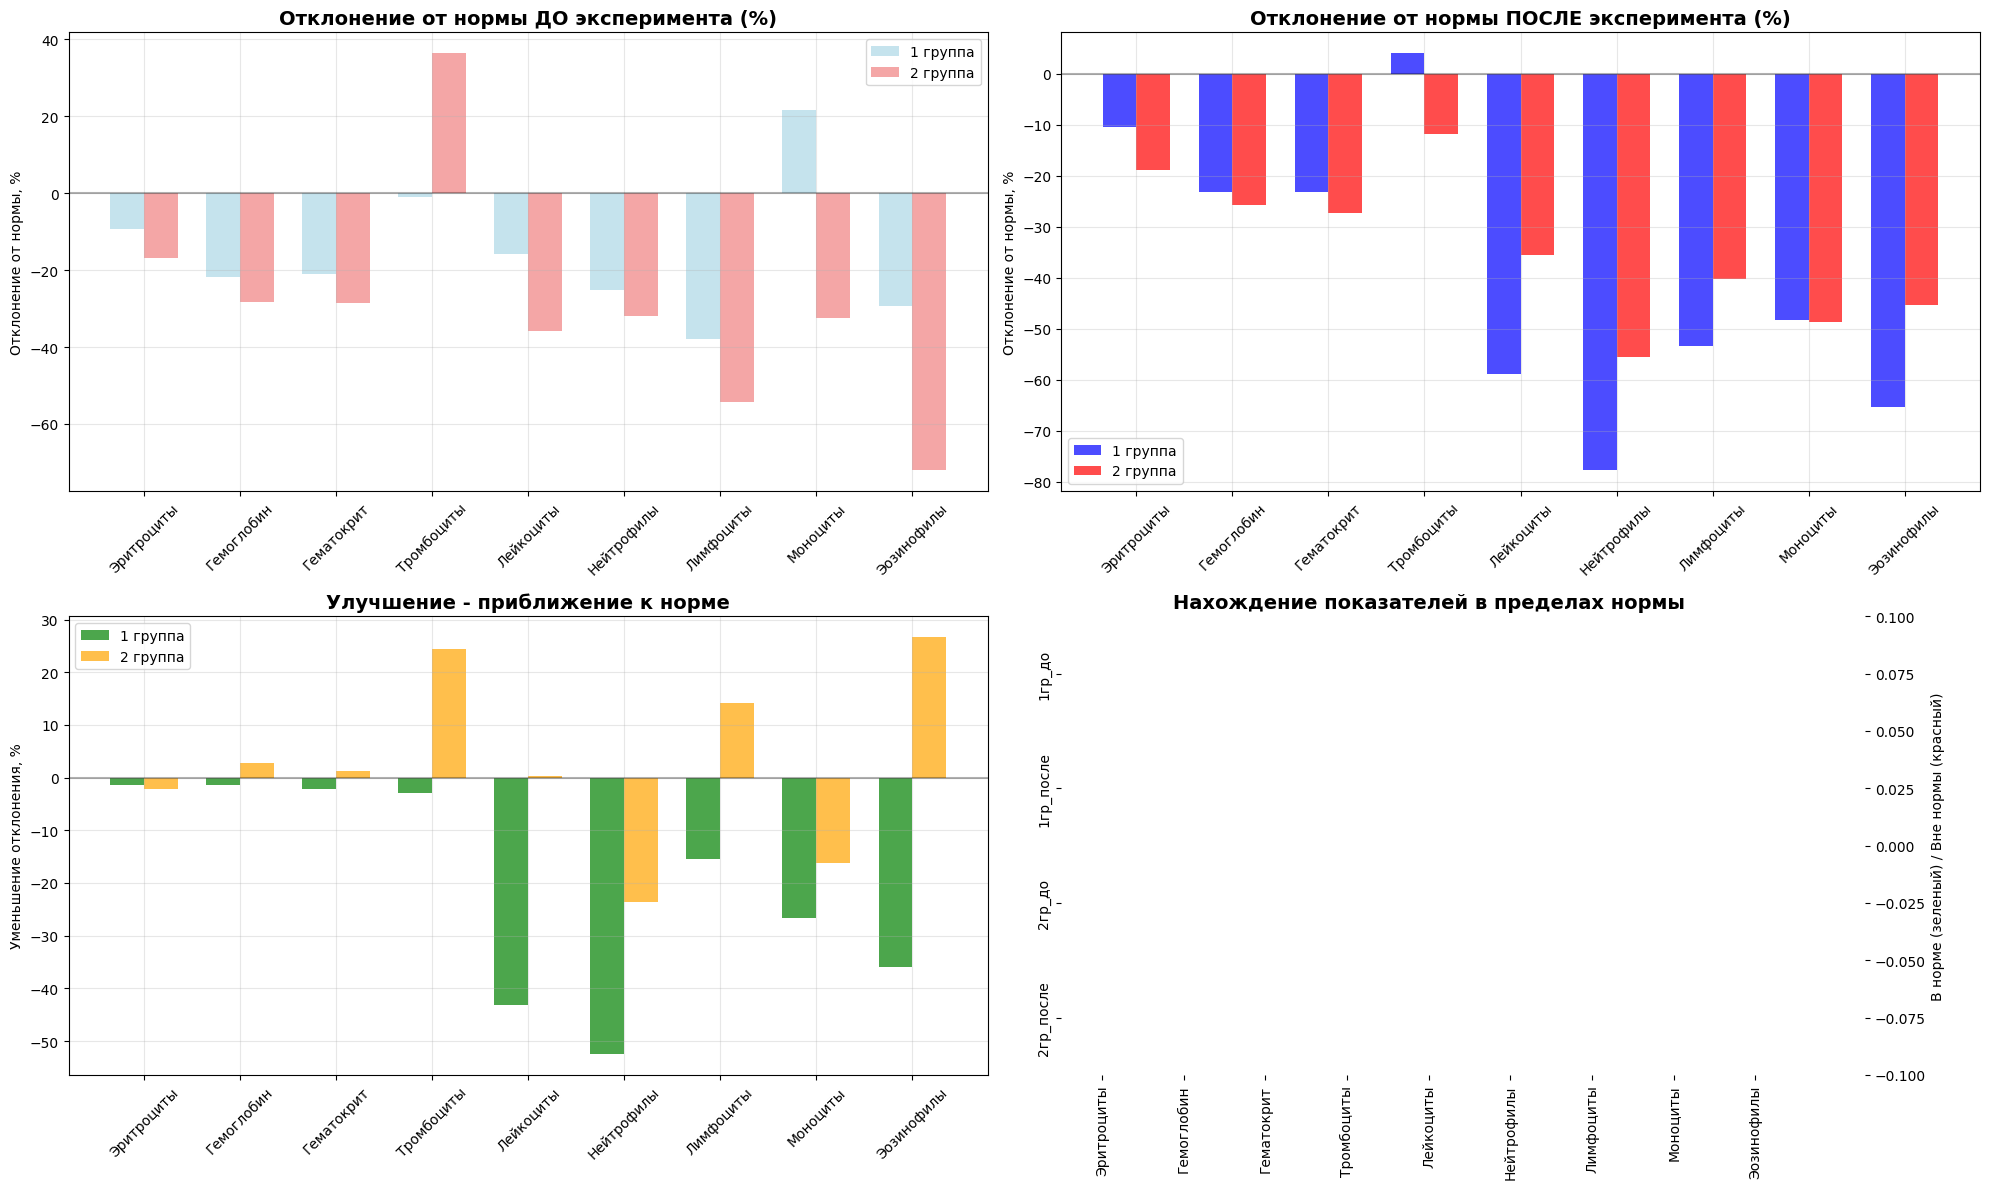


СТАТИСТИЧЕСКИЙ АНАЛИЗ ЭФФЕКТИВНОСТИ ВОССТАНОВЛЕНИЯ НОРМЫ
Статистический анализ улучшений:
Среднее улучшение 1 группы: -20.20%
Среднее улучшение 2 группы: 3.04%
T-статистика: -2.6658
P-значение: 0.0169
Статистически значимые различия: ДА

Показателей в пределах нормы:
1 группа: ДО - 9/9, ПОСЛЕ - 7/9
2 группа: ДО - 7/9, ПОСЛЕ - 8/9

Эффективность восстановления нормы:
1 группа лучше восстановила: 1 показателей
2 группа лучше восстановила: 8 показателей
Одинаковая эффективность: 0 показателей

ОБЩИЕ ВЫВОДЫ:
✅ 2 группа демонстрирует лучшую эффективность восстановления нормы
✅ 2 группа имеет больше показателей в норме после эксперимента


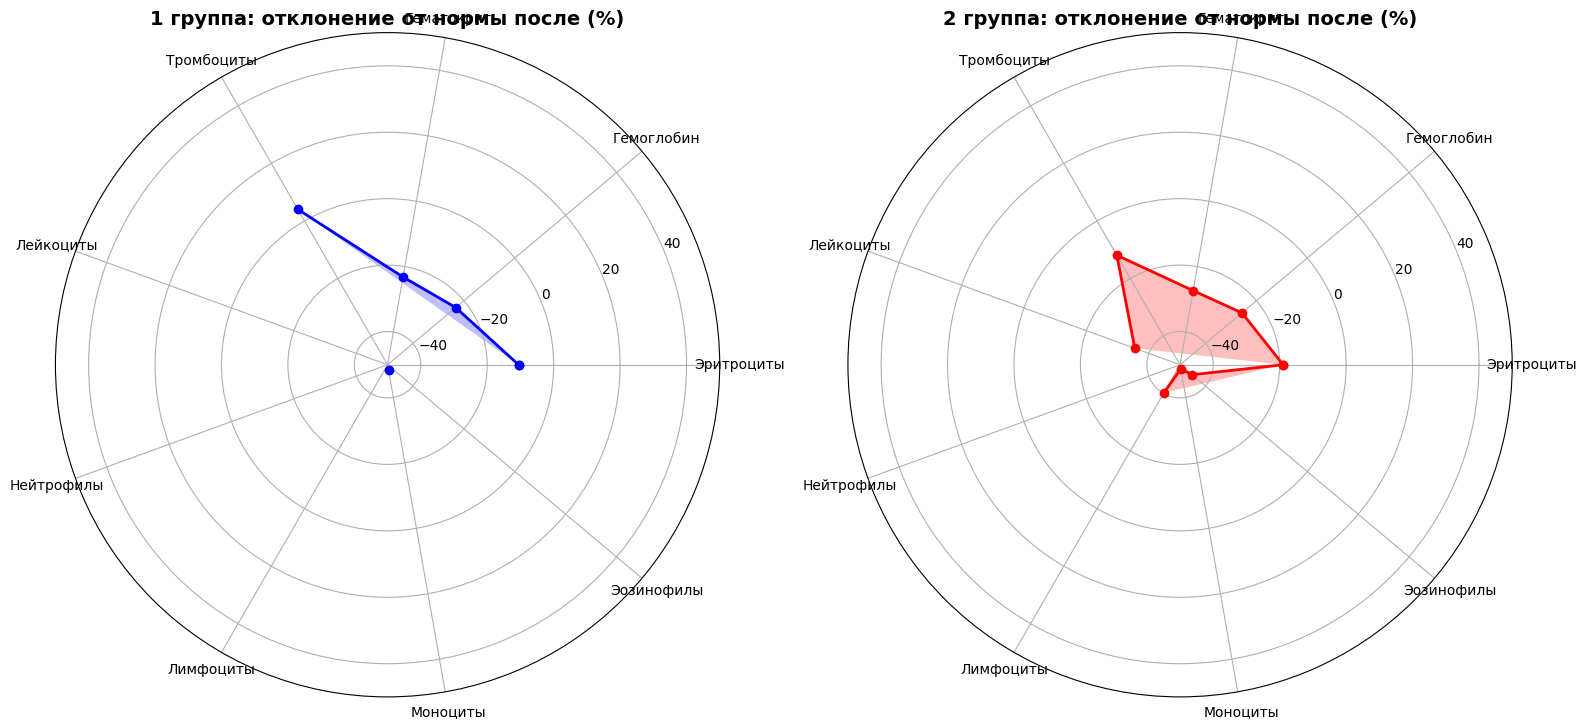

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Установим русский шрифт для графиков
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Исходные данные по всем кроликам
raw_data = {
    '1 группа': {
        'Эритроциты_до': [5.92, 5.1, 4.64], 'Эритроциты_после': [5.48, 5.31, 4.64],
        'Гемоглобин_до': [116, 101, 100], 'Гемоглобин_после': [111, 99, 101],
        'Гематокрит_до': [34.9, 30.4, 29.6], 'Гематокрит_после': [33.1, 29.9, 29.2],
        'Тромбоциты_до': [137, 671, 528], 'Тромбоциты_после': [145, 686, 573],
        'Лейкоциты_до': [9.9, 5.34, 6.25], 'Лейкоциты_после': [2.74, 3.48, 4.25],
        'Нейтрофилы_до': [3.32, 3.52, 2.69], 'Нейтрофилы_после': [0.52, 0.99, 1.33],
        'Лимфоциты_до': [4.27, 1.43, 2.21], 'Лимфоциты_после': [1.68, 1.96, 2.3],
        'Моноциты_до': [1.62, 0.25, 1.05], 'Моноциты_после': [0.24, 0.46, 0.54],
        'Эозинофилы_до': [0.16, 0.13, 0.24], 'Эозинофилы_после': [0.13, 0.06, 0.07]
    },
    '2 группа': {
        'Эритроциты_до': [4.75, 4.96, 4.63], 'Эритроциты_после': [4.71, 4.12, 5.15],
        'Гемоглобин_до': [97, 102, 91], 'Гемоглобин_после': [103, 95, 103],
        'Гематокрит_до': [28.5, 30.5, 26.8], 'Гематокрит_после': [29.1, 26.9, 31.2],
        'Тромбоциты_до': [960, 433, 448], 'Тромбоциты_после': [339, 428, 422],
        'Лейкоциты_до': [6.57, 6.41, 3.4], 'Лейкоциты_после': [3.33, 2.75, 10.37],
        'Нейтрофилы_до': [4.74, 2.72, 1.22], 'Нейтрофилы_после': [1.14, 0.84, 3.68],
        'Лимфоциты_до': [1.15, 2.83, 1.84], 'Лимфоциты_после': [1.6, 1.32, 4.7],
        'Моноциты_до': [0.6, 0.72, 0.3], 'Моноциты_после': [0.49, 0.49, 0.25],
        'Эозинофилы_до': [0.07, 0.1, 0.04], 'Эозинофилы_после': [0.05, 0.11, 0.25]
    }
}

# НОРМАЛЬНЫЕ ПОКАЗАТЕЛИ ДЛЯ КРОЛИКОВ (референсные значения)
control_ranges = {
    'Эритроциты': [4.5, 7.0],      # млн/мкл
    'Гемоглобин': [100, 170],       # г/л
    'Гематокрит': [30, 50],         # %
    'Тромбоциты': [250, 650],       # тыс/мкл
    'Лейкоциты': [5.0, 12.0],      # тыс/мкл
    'Нейтрофилы': [1.5, 7.0],      # тыс/мкл
    'Лимфоциты': [1.5, 7.0],       # тыс/мкл
    'Моноциты': [0.1, 1.5],        # тыс/мкл
    'Эозинофилы': [0.0, 0.5]       # тыс/мкл
}

# Средние значения нормы (для анализа)
control_means = {indicator: np.mean(range_val) for indicator, range_val in control_ranges.items()}

indicators = list(control_ranges.keys())

# АНАЛИЗ ОТКЛОНЕНИЙ ОТ НОРМЫ
analysis_results = []

for indicator in indicators:
    control_min, control_max = control_ranges[indicator]
    control_mean = control_means[indicator]
    
    # Анализ для 1 группы
    g1_before = np.mean(raw_data['1 группа'][f'{indicator}_до'])
    g1_after = np.mean(raw_data['1 группа'][f'{indicator}_после'])
    
    # Анализ для 2 группы
    g2_before = np.mean(raw_data['2 группа'][f'{indicator}_до'])
    g2_after = np.mean(raw_data['2 группа'][f'{indicator}_после'])
    
    # Отклонения от нормы в %
    g1_before_dev = ((g1_before - control_mean) / control_mean) * 100
    g1_after_dev = ((g1_after - control_mean) / control_mean) * 100
    g2_before_dev = ((g2_before - control_mean) / control_mean) * 100
    g2_after_dev = ((g2_after - control_mean) / control_mean) * 100
    
    # Находится ли в норме?
    g1_before_in_range = control_min <= g1_before <= control_max
    g1_after_in_range = control_min <= g1_after <= control_max
    g2_before_in_range = control_min <= g2_before <= control_max
    g2_after_in_range = control_min <= g2_after <= control_max
    
    # Улучшение (приближение к норме)
    g1_improvement = abs(g1_before_dev) - abs(g1_after_dev)
    g2_improvement = abs(g2_before_dev) - abs(g2_after_dev)
    
    analysis_results.append({
        'Показатель': indicator,
        'Норма': f'{control_min}-{control_max}',
        'Норма_среднее': control_mean,
        
        '1гр_до': g1_before,
        '1гр_после': g1_after,
        '1гр_отклонение_до_%': g1_before_dev,
        '1гр_отклонение_после_%': g1_after_dev,
        '1гр_в_норме_до': g1_before_in_range,
        '1гр_в_норме_после': g1_after_in_range,
        '1гр_улучшение': g1_improvement,
        
        '2гр_до': g2_before,
        '2гр_после': g2_after,
        '2гр_отклонение_до_%': g2_before_dev,
        '2гр_отклонение_после_%': g2_after_dev,
        '2гр_в_норме_до': g2_before_in_range,
        '2гр_в_норме_после': g2_after_in_range,
        '2гр_улучшение': g2_improvement,
        
        'Лучшее_улучшение': '1 группа' if g1_improvement > g2_improvement else '2 группа' if g2_improvement > g1_improvement else 'одинаково'
    })

df_analysis = pd.DataFrame(analysis_results)

print("АНАЛИЗ КРОВИ КРОЛИКОВ С УЧЕТОМ НОРМЫ")
print("="*80)
print(df_analysis.round(3))

# ВИЗУАЛИЗАЦИЯ: Отклонения от нормы
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# 1. Отклонения от нормы ДО эксперимента
x_pos = np.arange(len(indicators))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, df_analysis['1гр_отклонение_до_%'], width, 
                label='1 группа', color='lightblue', alpha=0.7)
bars2 = ax1.bar(x_pos + width/2, df_analysis['2гр_отклонение_до_%'], width, 
                label='2 группа', color='lightcoral', alpha=0.7)

ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax1.set_title('Отклонение от нормы ДО эксперимента (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Отклонение от нормы, %')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(indicators, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Отклонения от нормы ПОСЛЕ эксперимента
bars3 = ax2.bar(x_pos - width/2, df_analysis['1гр_отклонение_после_%'], width, 
                label='1 группа', color='blue', alpha=0.7)
bars4 = ax2.bar(x_pos + width/2, df_analysis['2гр_отклонение_после_%'], width, 
                label='2 группа', color='red', alpha=0.7)

ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_title('Отклонение от нормы ПОСЛЕ эксперимента (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Отклонение от нормы, %')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(indicators, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Улучшение (приближение к норме)
bars5 = ax3.bar(x_pos - width/2, df_analysis['1гр_улучшение'], width, 
                label='1 группа', color='green', alpha=0.7)
bars6 = ax3.bar(x_pos + width/2, df_analysis['2гр_улучшение'], width, 
                label='2 группа', color='orange', alpha=0.7)

ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax3.set_title('Улучшение - приближение к норме', fontsize=14, fontweight='bold')
ax3.set_ylabel('Уменьшение отклонения, %')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(indicators, rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Тепловая карта нахождения в норме
norm_data = pd.DataFrame({
    '1гр_до': df_analysis['1гр_в_норме_до'].map({True: 'В норме', False: 'Вне нормы'}),
    '1гр_после': df_analysis['1гр_в_норме_после'].map({True: 'В норме', False: 'Вне нормы'}),
    '2гр_до': df_analysis['2гр_в_норме_до'].map({True: 'В норме', False: 'Вне нормы'}),
    '2гр_после': df_analysis['2гр_в_норме_после'].map({True: 'В норме', False: 'Вне нормы'})
}, index=indicators)

# Создаем числовую матрицу для тепловой карты
norm_numeric = pd.DataFrame({
    '1гр_до': df_analysis['1гр_в_норме_до'].map({True: 1, False: 0}),
    '1гр_после': df_analysis['1гр_в_норме_после'].map({True: 1, False: 0}),
    '2гр_до': df_analysis['2гр_в_норме_до'].map({True: 1, False: 0}),
    '2гр_после': df_analysis['2гр_в_норме_после'].map({True: 1, False: 0})
}, index=indicators)

sns.heatmap(norm_numeric.T, annot=norm_data.T.values, fmt='', 
            cmap=['red', 'green'], center=0.5,
            cbar_kws={'label': 'В норме (зеленый) / Вне нормы (красный)'},
            ax=ax4)
ax4.set_title('Нахождение показателей в пределах нормы', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# СТАТИСТИЧЕСКИЙ АНАЛИЗ УЛУЧШЕНИЙ
print("\n" + "="*80)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ЭФФЕКТИВНОСТИ ВОССТАНОВЛЕНИЯ НОРМЫ")
print("="*80)

# T-тест для улучшений между группами
improvements_1 = df_analysis['1гр_улучшение'].values
improvements_2 = df_analysis['2гр_улучшение'].values

t_stat, p_value = stats.ttest_ind(improvements_1, improvements_2)

print(f"Статистический анализ улучшений:")
print(f"Среднее улучшение 1 группы: {np.mean(improvements_1):.2f}%")
print(f"Среднее улучшение 2 группы: {np.mean(improvements_2):.2f}%")
print(f"T-статистика: {t_stat:.4f}")
print(f"P-значение: {p_value:.4f}")
print(f"Статистически значимые различия: {'ДА' if p_value < 0.05 else 'НЕТ'}")

# Анализ по количеству показателей в норме
g1_before_in_norm = sum(df_analysis['1гр_в_норме_до'])
g1_after_in_norm = sum(df_analysis['1гр_в_норме_после'])
g2_before_in_norm = sum(df_analysis['2гр_в_норме_до'])
g2_after_in_norm = sum(df_analysis['2гр_в_норме_после'])

print(f"\nПоказателей в пределах нормы:")
print(f"1 группа: ДО - {g1_before_in_norm}/9, ПОСЛЕ - {g1_after_in_norm}/9")
print(f"2 группа: ДО - {g2_before_in_norm}/9, ПОСЛЕ - {g2_after_in_norm}/9")

# Анализ лучшего улучшения
better_1 = sum(df_analysis['Лучшее_улучшение'] == '1 группа')
better_2 = sum(df_analysis['Лучшее_улучшение'] == '2 группа')
equal = sum(df_analysis['Лучшее_улучшение'] == 'одинаково')

print(f"\nЭффективность восстановления нормы:")
print(f"1 группа лучше восстановила: {better_1} показателей")
print(f"2 группа лучше восстановила: {better_2} показателей")
print(f"Одинаковая эффективность: {equal} показателей")

# ВЫВОДЫ
print("\n" + "="*80)
print("ОБЩИЕ ВЫВОДЫ:")
print("="*80)

if better_1 > better_2:
    print("✅ 1 группа демонстрирует лучшую эффективность восстановления нормы")
elif better_2 > better_1:
    print("✅ 2 группа демонстрирует лучшую эффективность восстановления нормы")
else:
    print("⚠️  Группы демонстрируют сопоставимую эффективность")

if g1_after_in_norm > g2_after_in_norm:
    print("✅ 1 группа имеет больше показателей в норме после эксперимента")
elif g2_after_in_norm > g1_after_in_norm:
    print("✅ 2 группа имеет больше показателей в норме после эксперимента")
else:
    print("⚠️  Группы имеют одинаковое количество показателей в норме")

print("="*80)

# ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: Радар-диаграмма отклонений от нормы
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(projection='polar'))

# Функция для создания радар-диаграммы
def create_radar_chart(ax, values, title, color):
    categories = indicators
    N = len(categories)
    
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    values = list(values) + [values[0]]
    
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=title)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(-50, 50)
    ax.set_title(title, size=14, fontweight='bold')
    ax.grid(True)

# Радар-диаграмма для отклонений ПОСЛЕ эксперимента
create_radar_chart(ax5, df_analysis['1гр_отклонение_после_%'], 
                  '1 группа: отклонение от нормы после (%)', 'blue')
create_radar_chart(ax6, df_analysis['2гр_отклонение_после_%'], 
                  '2 группа: отклонение от нормы после (%)', 'red')

plt.tight_layout()
plt.show()

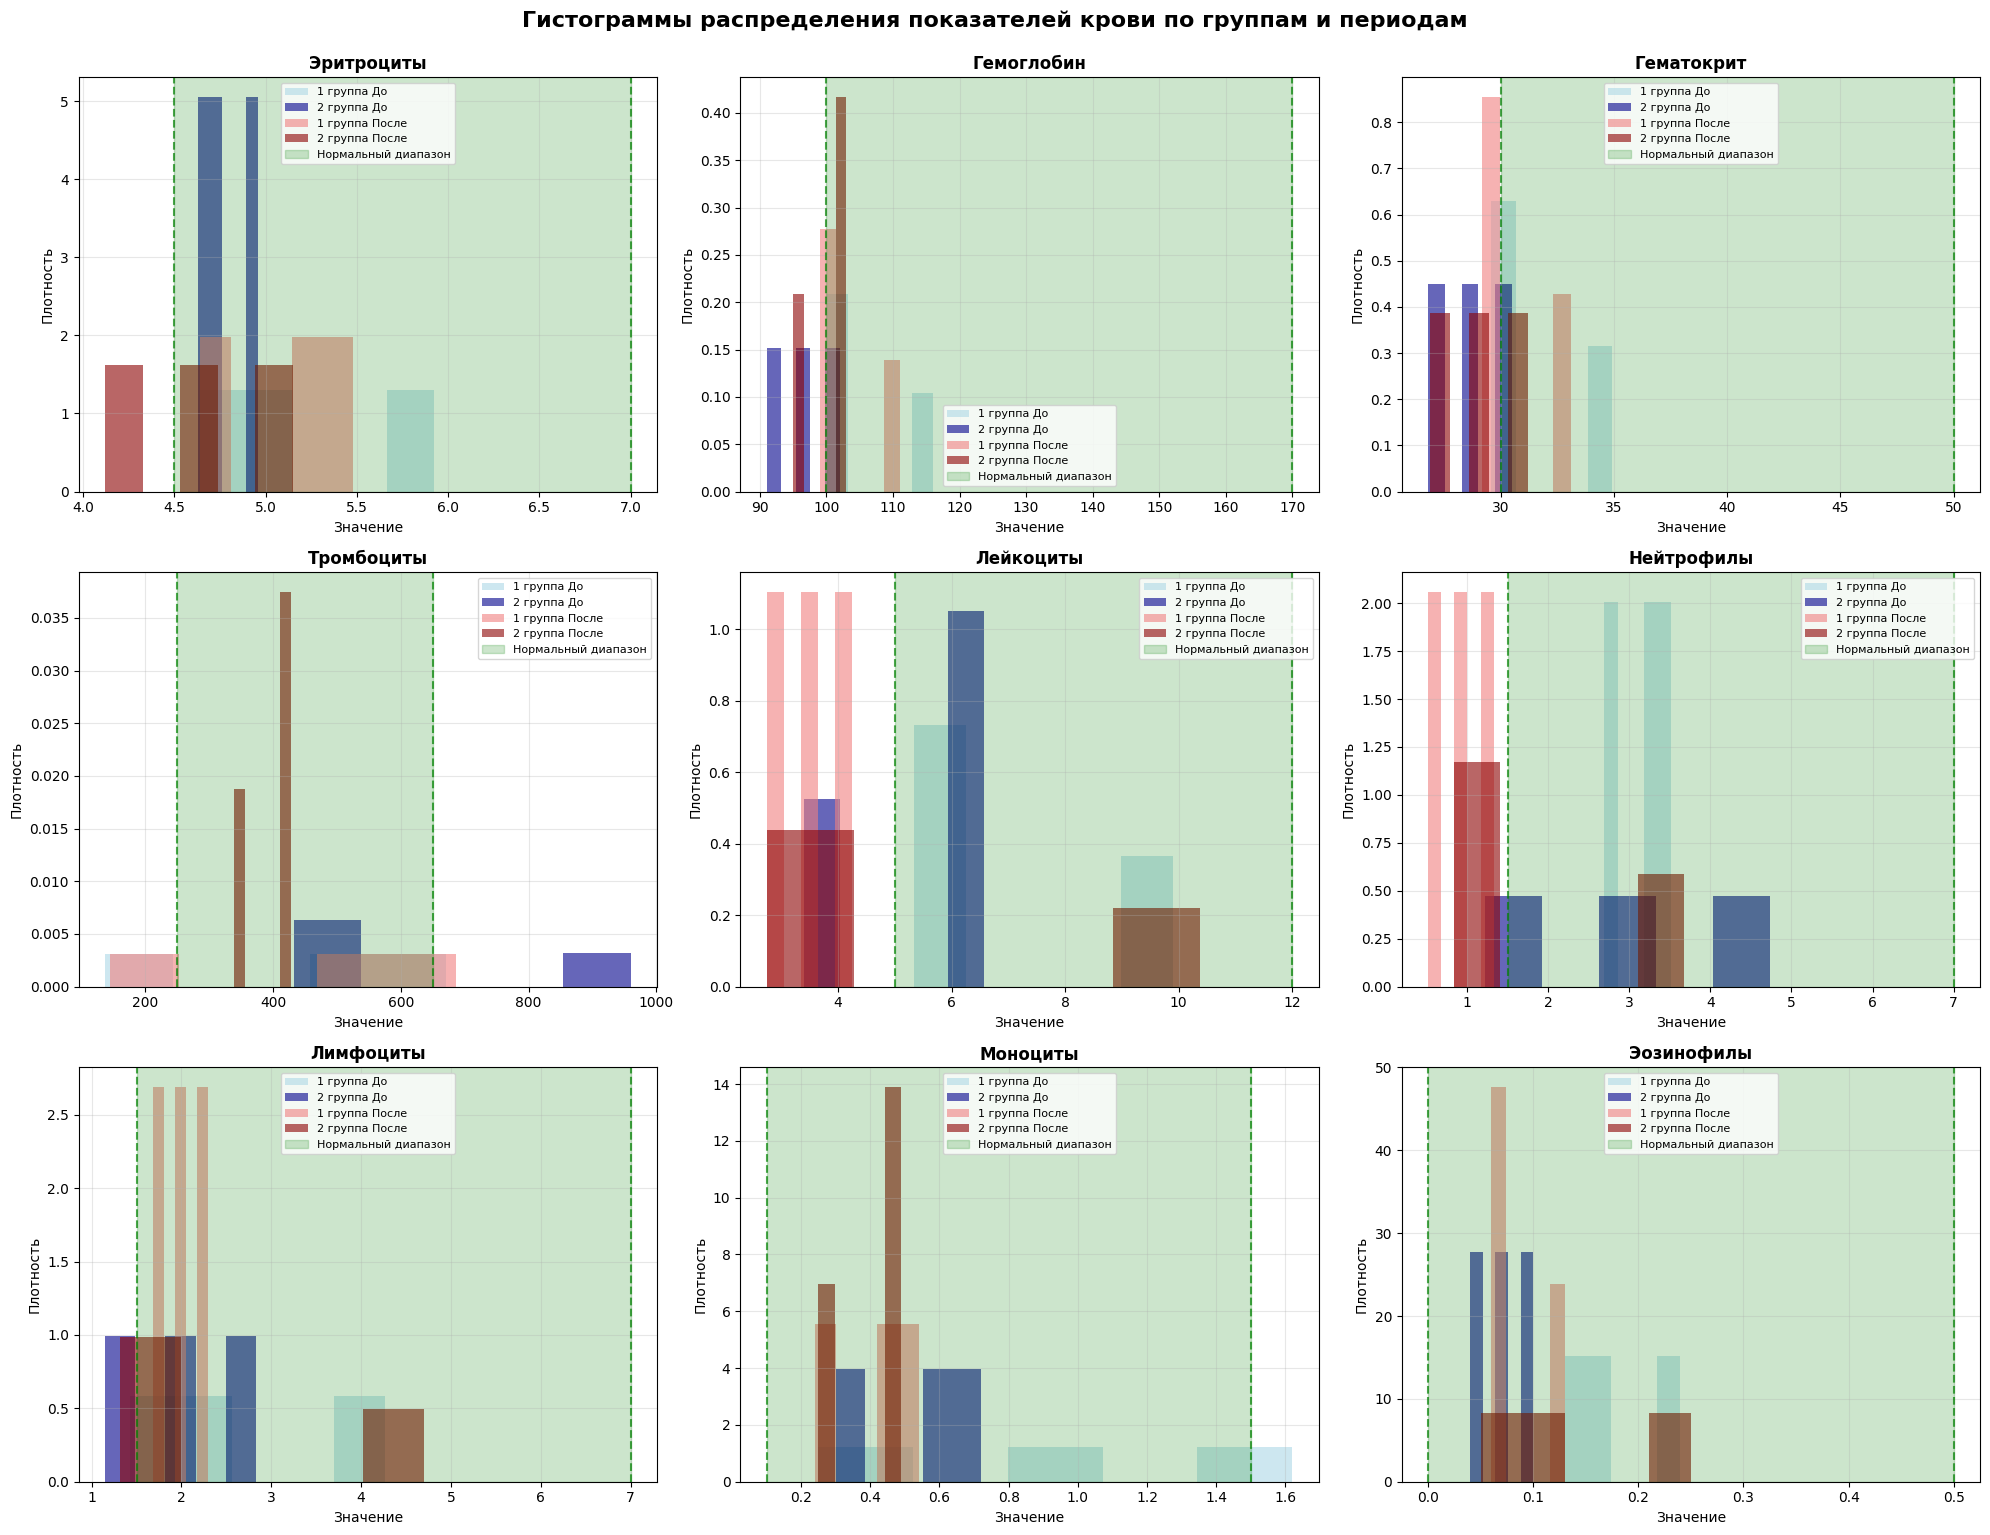

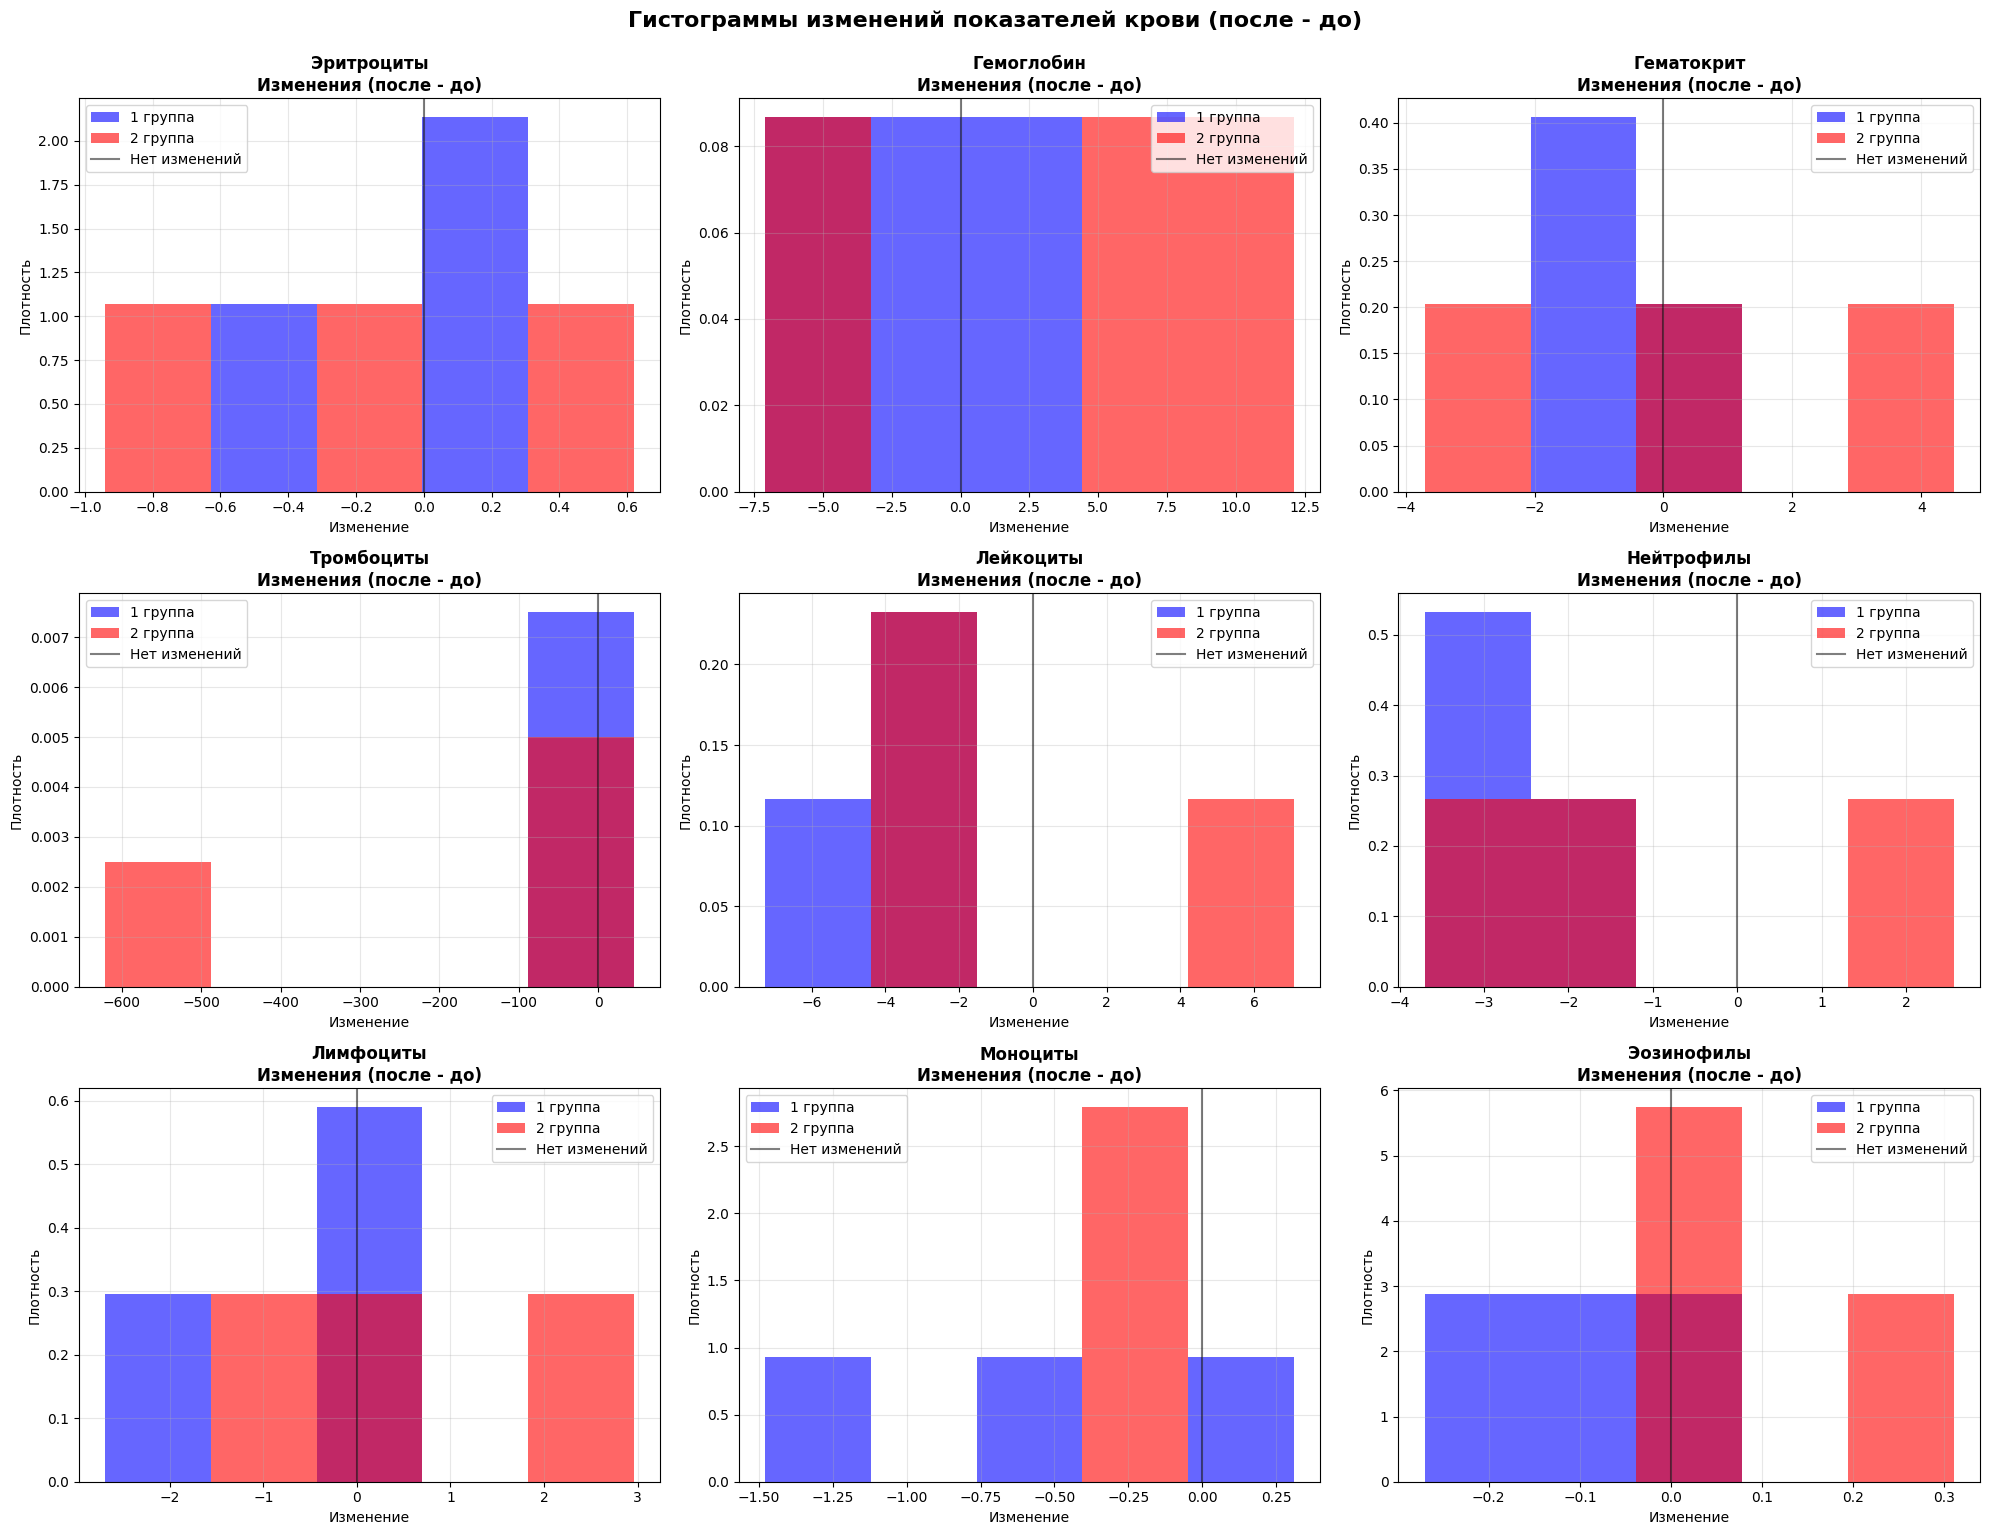

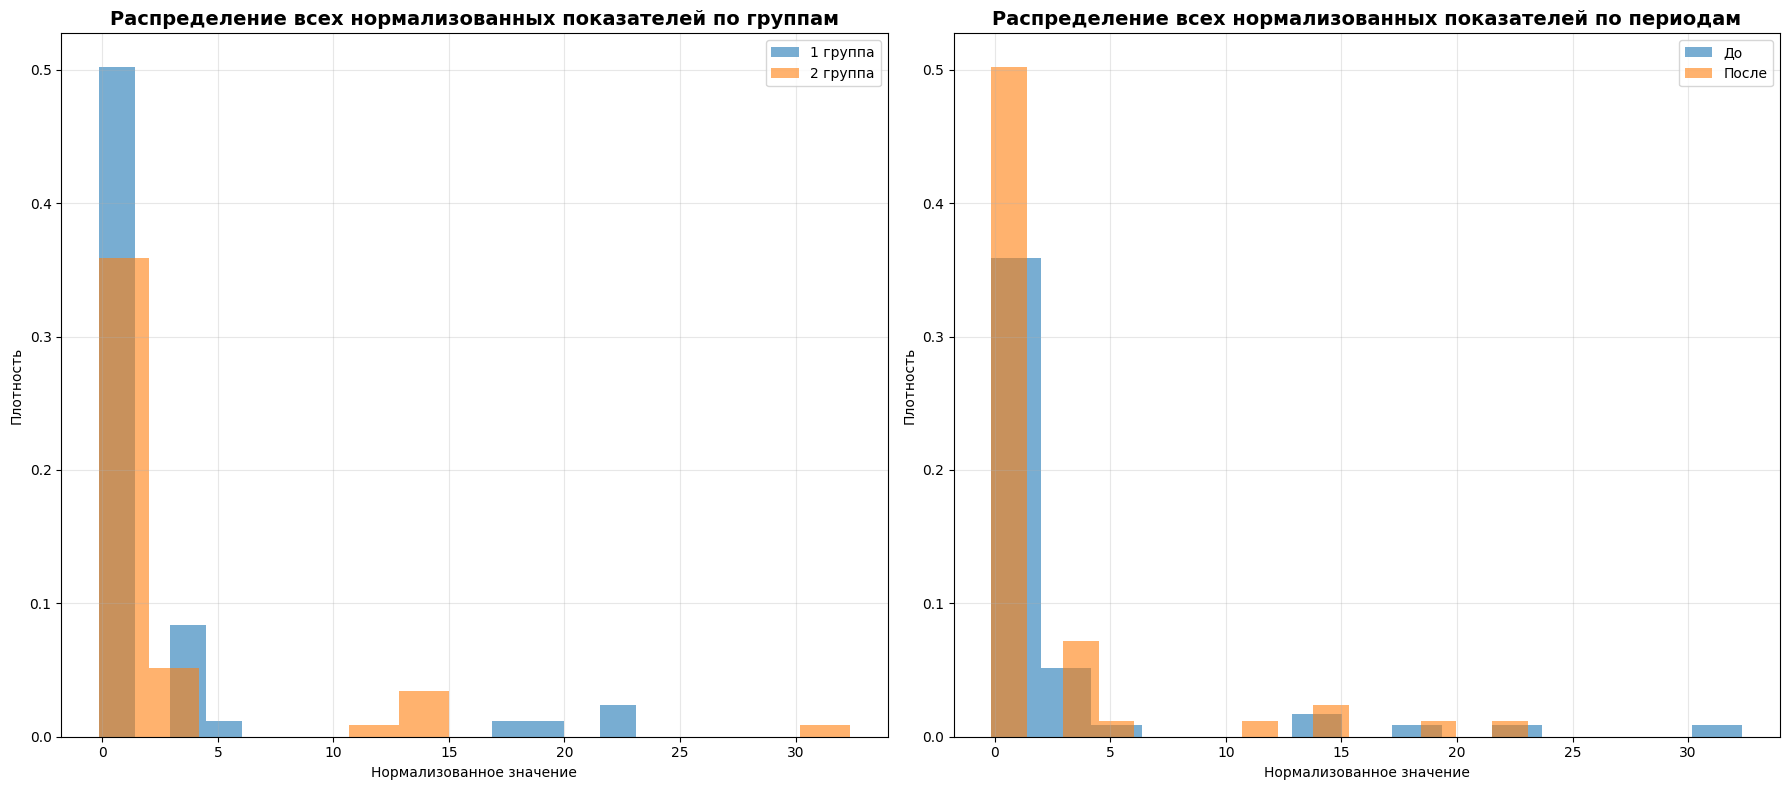

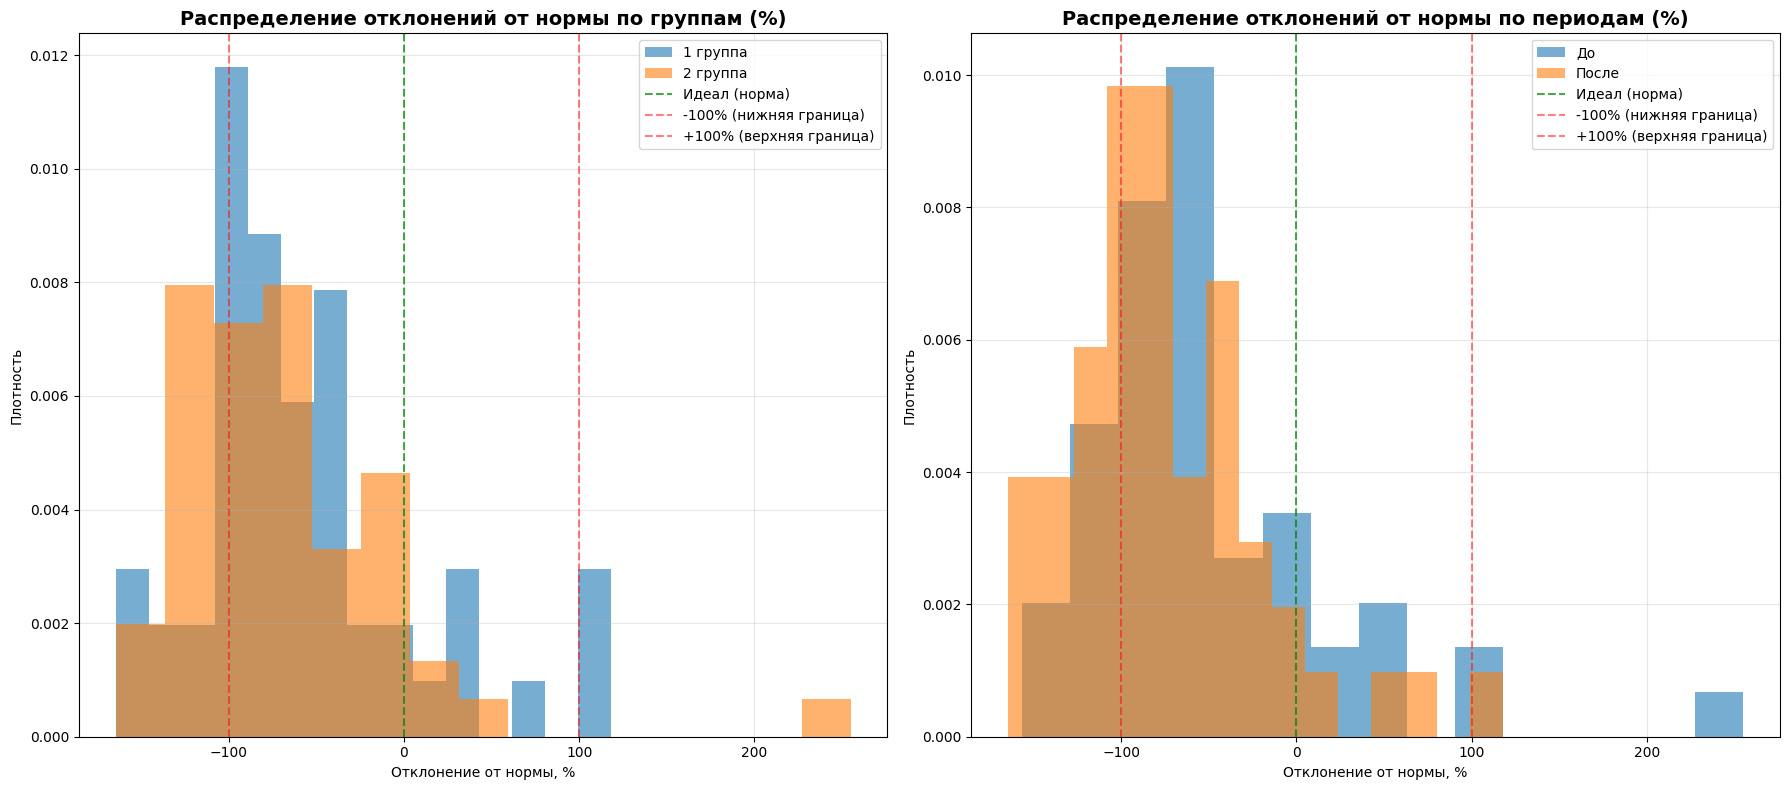

СТАТИСТИЧЕСКИЙ АНАЛИЗ РАСПРЕДЕЛЕНИЙ ПОКАЗАТЕЛЕЙ
1 группа: Тест Шапиро-Уилка p-value = 0.0000 (не нормальное)
2 группа: Тест Шапиро-Уилка p-value = 0.0000 (не нормальное)

T-тест между группами: p-value = 0.8917 (нет значимых различий)

АНАЛИЗ ИЗМЕНЕНИЙ ПО ПЕРИОДАМ:
До: среднее = 2.395, std = 6.215
После: среднее = 2.017, std = 4.925
T-тест между периодами: p-value = 0.7288 (нет значимых изменений)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Установим русский шрифт для графиков
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Исходные данные по всем кроликам
raw_data = {
    '1 группа': {
        'Эритроциты_до': [5.92, 5.1, 4.64], 'Эритроциты_после': [5.48, 5.31, 4.64],
        'Гемоглобин_до': [116, 101, 100], 'Гемоглобин_после': [111, 99, 101],
        'Гематокрит_до': [34.9, 30.4, 29.6], 'Гематокрит_после': [33.1, 29.9, 29.2],
        'Тромбоциты_до': [137, 671, 528], 'Тромбоциты_после': [145, 686, 573],
        'Лейкоциты_до': [9.9, 5.34, 6.25], 'Лейкоциты_после': [2.74, 3.48, 4.25],
        'Нейтрофилы_до': [3.32, 3.52, 2.69], 'Нейтрофилы_после': [0.52, 0.99, 1.33],
        'Лимфоциты_до': [4.27, 1.43, 2.21], 'Лимфоциты_после': [1.68, 1.96, 2.3],
        'Моноциты_до': [1.62, 0.25, 1.05], 'Моноциты_после': [0.24, 0.46, 0.54],
        'Эозинофилы_до': [0.16, 0.13, 0.24], 'Эозинофилы_после': [0.13, 0.06, 0.07]
    },
    '2 группа': {
        'Эритроциты_до': [4.75, 4.96, 4.63], 'Эритроциты_после': [4.71, 4.12, 5.15],
        'Гемоглобин_до': [97, 102, 91], 'Гемоглобин_после': [103, 95, 103],
        'Гематокрит_до': [28.5, 30.5, 26.8], 'Гематокрит_после': [29.1, 26.9, 31.2],
        'Тромбоциты_до': [960, 433, 448], 'Тромбоциты_после': [339, 428, 422],
        'Лейкоциты_до': [6.57, 6.41, 3.4], 'Лейкоциты_после': [3.33, 2.75, 10.37],
        'Нейтрофилы_до': [4.74, 2.72, 1.22], 'Нейтрофилы_после': [1.14, 0.84, 3.68],
        'Лимфоциты_до': [1.15, 2.83, 1.84], 'Лимфоциты_после': [1.6, 1.32, 4.7],
        'Моноциты_до': [0.6, 0.72, 0.3], 'Моноциты_после': [0.49, 0.49, 0.25],
        'Эозинофилы_до': [0.07, 0.1, 0.04], 'Эозинофилы_после': [0.05, 0.11, 0.25]
    }
}

# НОРМАЛЬНЫЕ ПОКАЗАТЕЛИ ДЛЯ КРОЛИКОВ
control_ranges = {
    'Эритроциты': [4.5, 7.0],
    'Гемоглобин': [100, 170],
    'Гематокрит': [30, 50],
    'Тромбоциты': [250, 650],
    'Лейкоциты': [5.0, 12.0],
    'Нейтрофилы': [1.5, 7.0],
    'Лимфоциты': [1.5, 7.0],
    'Моноциты': [0.1, 1.5],
    'Эозинофилы': [0.0, 0.5]
}

indicators = list(control_ranges.keys())

# ПОДГОТОВКА ДАННЫХ ДЛЯ ГИСТОГРАММ
# Создаем DataFrame с индивидуальными значениями всех кроликов
individual_data = []

for indicator in indicators:
    # 1 группа - до
    for i, value in enumerate(raw_data['1 группа'][f'{indicator}_до']):
        individual_data.append({
            'Показатель': indicator,
            'Группа': '1 группа',
            'Период': 'До',
            'Значение': value,
            'Норма_мин': control_ranges[indicator][0],
            'Норма_макс': control_ranges[indicator][1]
        })
    
    # 1 группа - после
    for i, value in enumerate(raw_data['1 группа'][f'{indicator}_после']):
        individual_data.append({
            'Показатель': indicator,
            'Группа': '1 группа',
            'Период': 'После',
            'Значение': value,
            'Норма_мин': control_ranges[indicator][0],
            'Норма_макс': control_ranges[indicator][1]
        })
    
    # 2 группа - до
    for i, value in enumerate(raw_data['2 группа'][f'{indicator}_до']):
        individual_data.append({
            'Показатель': indicator,
            'Группа': '2 группа',
            'Период': 'До',
            'Значение': value,
            'Норма_мин': control_ranges[indicator][0],
            'Норма_макс': control_ranges[indicator][1]
        })
    
    # 2 группа - после
    for i, value in enumerate(raw_data['2 группа'][f'{indicator}_после']):
        individual_data.append({
            'Показатель': indicator,
            'Группа': '2 группа',
            'Период': 'После',
            'Значение': value,
            'Норма_мин': control_ranges[indicator][0],
            'Норма_макс': control_ranges[indicator][1]
        })

df_individual = pd.DataFrame(individual_data)

# ГИСТОГРАММЫ ДЛЯ КАЖДОГО ПОКАЗАТЕЛЯ
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for idx, indicator in enumerate(indicators):
    if idx >= len(axes):
        break
        
    ax = axes[idx]
    
    # Фильтруем данные для текущего показателя
    data_subset = df_individual[df_individual['Показатель'] == indicator]
    
    # Создаем гистограммы для каждой группы и периода
    periods = ['До', 'После']
    colors = ['lightblue', 'darkblue', 'lightcoral', 'darkred']
    
    for i, period in enumerate(periods):
        for j, group in enumerate(['1 группа', '2 группа']):
            color_idx = i * 2 + j
            group_data = data_subset[
                (data_subset['Период'] == period) & 
                (data_subset['Группа'] == group)
            ]['Значение']
            
            # Гистограмма
            ax.hist(group_data, alpha=0.6, color=colors[color_idx], 
                   label=f'{group} {period}', bins=5, density=True)
    
    # Добавляем линии нормальных значений
    norm_min = control_ranges[indicator][0]
    norm_max = control_ranges[indicator][1]
    ylim = ax.get_ylim()
    
    ax.axvspan(norm_min, norm_max, alpha=0.2, color='green', label='Нормальный диапазон')
    ax.axvline(norm_min, color='green', linestyle='--', alpha=0.7)
    ax.axvline(norm_max, color='green', linestyle='--', alpha=0.7)
    
    ax.set_title(f'{indicator}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Гистограммы распределения показателей крови по группам и периодам', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

# ГИСТОГРАММЫ ИЗМЕНЕНИЙ (после - до)
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for idx, indicator in enumerate(indicators):
    if idx >= len(axes):
        break
        
    ax = axes[idx]
    
    # Рассчитываем изменения для каждого животного
    changes_1 = []
    changes_2 = []
    
    # 1 группа изменения
    for i in range(3):
        before = raw_data['1 группа'][f'{indicator}_до'][i]
        after = raw_data['1 группа'][f'{indicator}_после'][i]
        changes_1.append(after - before)
    
    # 2 группа изменения
    for i in range(3):
        before = raw_data['2 группа'][f'{indicator}_до'][i]
        after = raw_data['2 группа'][f'{indicator}_после'][i]
        changes_2.append(after - before)
    
    # Гистограмма изменений
    bins = np.linspace(min(changes_1 + changes_2) - 0.1, max(changes_1 + changes_2) + 0.1, 6)
    
    ax.hist(changes_1, alpha=0.6, color='blue', label='1 группа', bins=bins, density=True)
    ax.hist(changes_2, alpha=0.6, color='red', label='2 группа', bins=bins, density=True)
    
    # Линия нулевого изменения
    ax.axvline(0, color='black', linestyle='-', alpha=0.5, label='Нет изменений')
    
    ax.set_title(f'{indicator}\nИзменения (после - до)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Изменение')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Гистограммы изменений показателей крови (после - до)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

# СОВМЕЩЕННАЯ ГИСТОГРАММА ВСЕХ ПОКАЗАТЕЛЕЙ (нормализованных)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Нормализуем данные с помощью RobustScaler
all_values = df_individual['Значение'].values.reshape(-1, 1)
scaler = RobustScaler()
scaler.fit(all_values)

df_individual['Нормализованное_значение'] = scaler.transform(all_values)

# Гистограмма всех нормализованных значений по группам
for group in ['1 группа', '2 группа']:
    group_data = df_individual[df_individual['Группа'] == group]['Нормализованное_значение']
    ax1.hist(group_data, alpha=0.6, label=group, bins=15, density=True)

ax1.set_title('Распределение всех нормализованных показателей по группам', fontsize=14, fontweight='bold')
ax1.set_xlabel('Нормализованное значение')
ax1.set_ylabel('Плотность')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Гистограмма по периодам
for period in ['До', 'После']:
    period_data = df_individual[df_individual['Период'] == period]['Нормализованное_значение']
    ax2.hist(period_data, alpha=0.6, label=period, bins=15, density=True)

ax2.set_title('Распределение всех нормализованных показателей по периодам', fontsize=14, fontweight='bold')
ax2.set_xlabel('Нормализованное значение')
ax2.set_ylabel('Плотность')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ГИСТОГРАММА ОТКЛОНЕНИЙ ОТ НОРМЫ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Рассчитываем отклонения от нормы в %
df_individual['Отклонение_%'] = df_individual.apply(
    lambda row: ((row['Значение'] - (row['Норма_мин'] + row['Норма_макс'])/2) / 
                ((row['Норма_макс'] - row['Норма_мин'])/2)) * 100, 
    axis=1
)

# Гистограмма отклонений по группам
for group in ['1 группа', '2 группа']:
    group_data = df_individual[df_individual['Группа'] == group]['Отклонение_%']
    ax1.hist(group_data, alpha=0.6, label=group, bins=15, density=True)

ax1.axvline(0, color='green', linestyle='--', alpha=0.7, label='Идеал (норма)')
ax1.axvline(-100, color='red', linestyle='--', alpha=0.5, label='-100% (нижняя граница)')
ax1.axvline(100, color='red', linestyle='--', alpha=0.5, label='+100% (верхняя граница)')

ax1.set_title('Распределение отклонений от нормы по группам (%)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Отклонение от нормы, %')
ax1.set_ylabel('Плотность')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Гистограмма отклонений по периодам
for period in ['До', 'После']:
    period_data = df_individual[df_individual['Период'] == period]['Отклонение_%']
    ax2.hist(period_data, alpha=0.6, label=period, bins=15, density=True)

ax2.axvline(0, color='green', linestyle='--', alpha=0.7, label='Идеал (норма)')
ax2.axvline(-100, color='red', linestyle='--', alpha=0.5, label='-100% (нижняя граница)')
ax2.axvline(100, color='red', linestyle='--', alpha=0.5, label='+100% (верхняя граница)')

ax2.set_title('Распределение отклонений от нормы по периодам (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Отклонение от нормы, %')
ax2.set_ylabel('Плотность')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# СТАТИСТИЧЕСКИЙ АНАЛИЗ РАСПРЕДЕЛЕНИЙ
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ РАСПРЕДЕЛЕНИЙ ПОКАЗАТЕЛЕЙ")
print("="*60)

# Тест нормальности распределений
for group in ['1 группа', '2 группа']:
    group_data = df_individual[df_individual['Группа'] == group]['Нормализованное_значение']
    stat, p_value = stats.shapiro(group_data)
    print(f"{group}: Тест Шапиро-Уилка p-value = {p_value:.4f} ({'нормальное' if p_value > 0.05 else 'не нормальное'})")

print()

# T-тест между группами
group1_data = df_individual[df_individual['Группа'] == '1 группа']['Нормализованное_значение']
group2_data = df_individual[df_individual['Группа'] == '2 группа']['Нормализованное_значение']

t_stat, p_value = stats.ttest_ind(group1_data, group2_data)
print(f"T-тест между группами: p-value = {p_value:.4f} ({'значимые различия' if p_value < 0.05 else 'нет значимых различий'})")

# Анализ по периодам
print("\nАНАЛИЗ ИЗМЕНЕНИЙ ПО ПЕРИОДАМ:")
for period in ['До', 'После']:
    period_data = df_individual[df_individual['Период'] == period]['Нормализованное_значение']
    print(f"{period}: среднее = {np.mean(period_data):.3f}, std = {np.std(period_data):.3f}")

# Тест между периодами
before_data = df_individual[df_individual['Период'] == 'До']['Нормализованное_значение']
after_data = df_individual[df_individual['Период'] == 'После']['Нормализованное_значение']

t_stat, p_value = stats.ttest_ind(before_data, after_data)
print(f"T-тест между периодами: p-value = {p_value:.4f} ({'значимые изменения' if p_value < 0.05 else 'нет значимых изменений'})")

In [5]:
import numpy as np
import pandas as pd
from scipy import stats

# Данные из предыдущего анализа
raw_data = {
    '1 группа': {
        'Эритроциты_до': [5.92, 5.1, 4.64], 'Эритроциты_после': [5.48, 5.31, 4.64],
        'Гемоглобин_до': [116, 101, 100], 'Гемоглобин_после': [111, 99, 101],
        'Гематокрит_до': [34.9, 30.4, 29.6], 'Гематокрит_после': [33.1, 29.9, 29.2],
        'Тромбоциты_до': [137, 671, 528], 'Тромбоциты_после': [145, 686, 573],
        'Лейкоциты_до': [9.9, 5.34, 6.25], 'Лейкоциты_после': [2.74, 3.48, 4.25],
        'Нейтрофилы_до': [3.32, 3.52, 2.69], 'Нейтрофилы_после': [0.52, 0.99, 1.33],
        'Лимфоциты_до': [4.27, 1.43, 2.21], 'Лимфоциты_после': [1.68, 1.96, 2.3],
        'Моноциты_до': [1.62, 0.25, 1.05], 'Моноциты_после': [0.24, 0.46, 0.54],
        'Эозинофилы_до': [0.16, 0.13, 0.24], 'Эозинофилы_после': [0.13, 0.06, 0.07]
    },
    '2 группа': {
        'Эритроциты_до': [4.75, 4.96, 4.63], 'Эритроциты_после': [4.71, 4.12, 5.15],
        'Гемоглобин_до': [97, 102, 91], 'Гемоглобин_после': [103, 95, 103],
        'Гематокрит_до': [28.5, 30.5, 26.8], 'Гематокрит_после': [29.1, 26.9, 31.2],
        'Тромбоциты_до': [960, 433, 448], 'Тромбоциты_после': [339, 428, 422],
        'Лейкоциты_до': [6.57, 6.41, 3.4], 'Лейкоциты_после': [3.33, 2.75, 10.37],
        'Нейтрофилы_до': [4.74, 2.72, 1.22], 'Нейтрофилы_после': [1.14, 0.84, 3.68],
        'Лимфоциты_до': [1.15, 2.83, 1.84], 'Лимфоциты_после': [1.6, 1.32, 4.7],
        'Моноциты_до': [0.6, 0.72, 0.3], 'Моноциты_после': [0.49, 0.49, 0.25],
        'Эозинофилы_до': [0.07, 0.1, 0.04], 'Эозинофилы_после': [0.05, 0.11, 0.25]
    }
}

# Нормальные показатели для кроликов
control_ranges = {
    'Эритроциты': [4.5, 7.0],      # млн/мкл
    'Гемоглобин': [100, 170],       # г/л
    'Гематокрит': [30, 50],         # %
    'Тромбоциты': [250, 650],       # тыс/мкл
    'Лейкоциты': [5.0, 12.0],      # тыс/мкл
    'Нейтрофилы': [1.5, 7.0],      # тыс/мкл
    'Лимфоциты': [1.5, 7.0],       # тыс/мкл
    'Моноциты': [0.1, 1.5],        # тыс/мкл
    'Эозинофилы': [0.0, 0.5]       # тыс/мкл
}

indicators = list(control_ranges.keys())

# Функция для расчета M±m и проверки значимости отклонений от нормы
def calculate_stats_with_significance(group_data, indicator, period):
    values = group_data[f'{indicator}_{period}']
    mean = np.mean(values)
    std_error = np.std(values, ddof=1) / np.sqrt(len(values))
    
    # Проверка значимости отклонения от нормы
    control_min, control_max = control_ranges[indicator]
    control_mean = (control_min + control_max) / 2
    
    # Одновыборочный t-тест против среднего нормального значения
    t_stat, p_value = stats.ttest_1samp(values, control_mean)
    
    # Добавляем ** если p < 0.05
    significance = "**" if p_value < 0.05 else ""
    
    return f"{mean:.2f}±{std_error:.2f}{significance}"

# Создаем таблицу в формате как в примере
table_data = []

for indicator in indicators:
    control_min, control_max = control_ranges[indicator]
    
    row = {
        'Показатель': indicator,
        '1 группа до': calculate_stats_with_significance(raw_data['1 группа'], indicator, 'до'),
        '1 группа после': calculate_stats_with_significance(raw_data['1 группа'], indicator, 'после'),
        '2 группа до': calculate_stats_with_significance(raw_data['2 группа'], indicator, 'до'),
        '2 группа после': calculate_stats_with_significance(raw_data['2 группа'], indicator, 'после'),
        'Норма': f"{control_min}…{control_max}"
    }
    table_data.append(row)

# Создаем DataFrame
df_table = pd.DataFrame(table_data)

# Форматируем таблицу для красивого вывода
print("Таблица - Гематологические показатели у кроликов-носителей осшерий (M±m) (n=3)")
print("="*90)
print(f"{'Показатель':<15} {'1 группа до':<20} {'1 группа после':<20} {'2 группа до':<20} {'2 группа после':<20} {'Норма':<15}")
print("-"*90)

for _, row in df_table.iterrows():
    print(f"{row['Показатель']:<15} {row['1 группа до']:<20} {row['1 группа после']:<20} {row['2 группа до']:<20} {row['2 группа после']:<20} {row['Норма']:<15}")

print("="*90)
print("Примечание: p<0.05, ** - значительное отклонение от нормы")
print()

# ДОПОЛНИТЕЛЬНАЯ ТАБЛИЦА: Лейкоцитарная формула (как в примере с кошками)
print("\nТаблица - Лейкоцитарная формула у кроликов-носителей осшерий (M±m) (n=3)")
print("="*80)
print(f"{'Группа':<15} {'Лейкоциты, 10⁹/л':<20} {'в том числе':<50}")
print(f"{'':<15} {'':<20} {'Нейтрофилы, 10⁹/л':<20} {'Лимфоциты, 10⁹/л':<20} {'Моноциты, 10⁹/л':<20}")
print("-"*80)

# Данные для лейкоцитарной формулы
leukocyte_indicators = ['Лейкоциты', 'Нейтрофилы', 'Лимфоциты', 'Моноциты']

for group in ['1 группа до', '1 группа после', '2 группа до', '2 группа после']:
    group_name, period = group.split(' ')
    data_key = '1 группа' if group_name == '1' else '2 группа'
    
    leukocytes = calculate_stats_with_significance(raw_data[data_key], 'Лейкоциты', 'до' if period == 'до' else 'после')
    neutrophils = calculate_stats_with_significance(raw_data[data_key], 'Нейтрофилы', 'до' if period == 'до' else 'после')
    lymphocytes = calculate_stats_with_significance(raw_data[data_key], 'Лимфоциты', 'до' if period == 'до' else 'после')
    monocytes = calculate_stats_with_significance(raw_data[data_key], 'Моноциты', 'до' if period == 'до' else 'после')
    
    print(f"{group:<15} {leukocytes:<20} {neutrophils:<20} {lymphocytes:<20} {monocytes:<20}")

# Нормальные значения
print("-"*80)
print(f"{'Норма':<15} {'5.0…12.0':<20} {'1.5…7.0':<20} {'1.5…7.0':<20} {'0.1…1.5':<20}")
print("="*80)
print("Примечание: p<0.05, ** - значительное отклонение от нормы")

# СТАТИСТИЧЕСКИЙ АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ ГРУППАМИ
print("\n" + "="*60)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ ГРУППАМИ")
print("="*60)

significant_differences = []

for indicator in indicators:
    # Изменения в 1 группе
    g1_changes = []
    for i in range(3):
        before = raw_data['1 группа'][f'{indicator}_до'][i]
        after = raw_data['1 группа'][f'{indicator}_после'][i]
        g1_changes.append(after - before)
    
    # Изменения во 2 группе
    g2_changes = []
    for i in range(3):
        before = raw_data['2 группа'][f'{indicator}_до'][i]
        after = raw_data['2 группа'][f'{indicator}_после'][i]
        g2_changes.append(after - before)
    
    # T-тест для независимых выборок
    t_stat, p_value = stats.ttest_ind(g1_changes, g2_changes)
    
    if p_value < 0.05:
        significant_differences.append({
            'Показатель': indicator,
            'p_value': p_value,
            '1гр_изменение': np.mean(g1_changes),
            '2гр_изменение': np.mean(g2_changes)
        })

if significant_differences:
    print("Обнаружены статистически значимые различия в изменениях:")
    for diff in significant_differences:
        direction = "больше" if diff['2гр_изменение'] > diff['1гр_изменение'] else "меньше"
        print(f"  - {diff['Показатель']}: p = {diff['p_value']:.4f} (изменение во 2 группе {direction})")
else:
    print("Статистически значимых различий в изменениях между группами не обнаружено")

print("="*60)

# СОХРАНЕНИЕ ТАБЛИЦ В ФАЙЛ
with open('гематологические_показатели_кролики.txt', 'w', encoding='utf-8') as f:
    f.write("Таблица - Гематологические показатели у кроликов-носителей осшерий (M±m) (n=3)\n")
    f.write("="*90 + "\n")
    f.write(f"{'Показатель':<15} {'1 группа до':<20} {'1 группа после':<20} {'2 группа до':<20} {'2 группа после':<20} {'Норма':<15}\n")
    f.write("-"*90 + "\n")
    
    for _, row in df_table.iterrows():
        f.write(f"{row['Показатель']:<15} {row['1 группа до']:<20} {row['1 группа после']:<20} {row['2 группа до']:<20} {row['2 группа после']:<20} {row['Норма']:<15}\n")
    
    f.write("="*90 + "\n")
    f.write("Примечание: p<0.05, ** - значительное отклонение от нормы\n")

print("\nТаблицы сохранены в файл 'гематологические_показатели_кролики.txt'")

Таблица - Гематологические показатели у кроликов-носителей осшерий (M±m) (n=3)
Показатель      1 группа до          1 группа после       2 группа до          2 группа после       Норма          
------------------------------------------------------------------------------------------
Эритроциты      5.22±0.37            5.14±0.26            4.78±0.10**          4.66±0.30            4.5…7.0        
Гемоглобин      105.67±5.17**        103.67±3.71**        96.67±3.18**         100.33±2.67**        100…170        
Гематокрит      31.63±1.65**         30.73±1.20**         28.60±1.07**         29.07±1.24**         30…50          
Тромбоциты      445.33±159.60        468.00±164.76        613.67±173.22        396.33±28.72         250…650        
Лейкоциты       7.16±1.39            3.49±0.44**          5.46±1.03            5.48±2.45            5.0…12.0       
Нейтрофилы      3.18±0.25            0.95±0.23**          2.89±1.02            1.89±0.90            1.5…7.0        
Лимфоциты       2.

ValueError: too many values to unpack (expected 2)